# Greek-Neutral Hedging: A Unified Multi-Strategy Backtest

This notebook implements and compares five hedging strategies for a short options position
on a synthetic equity underlier. All strategies share a common base book, data pipeline,
and rebalancing framework so the comparison is like-for-like.

## Research question
Which Greek-neutral hedging strategy offers the best trade-off between residual risk reduction,
hedge coverage, and implementation cost across market regimes?

## Strategies compared
1. **Delta** — stock-only hedge  
2. **Delta-Gamma** — single-leg option hedge targeting gamma neutrality  
3. **Delta-Vega** — single-leg option hedge targeting vega neutrality  
4. **Delta-Theta** — single-leg option hedge targeting theta neutrality  
5. **Delta-Gamma-Vega (DGV)** — two-leg option hedge targeting simultaneous neutrality 


## 1. Imports

Make sure `fetch_data_hedging.py` is in the same folder as this notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.fetch_data_hedging_v2 import (
    build_synthetic_market_dataset,
    black_scholes_price,
    black_scholes_greeks,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## 2. User inputs

## Shared experiment configuration

This cell defines the common settings used across the unified backtest so that all strategies are evaluated under the same market environment and implementation assumptions.

### Market and sample settings
These parameters control the underlying asset, sample length, date range, expiry grid, and the constant continuous dividend yield used to generate dividend-aware synthetic option values.

### Initial book construction
We begin with a fixed underlying inventory and an initial base option position. In this setup, the base book starts with a short at the money call position at the target entry maturity, which serves as the core exposure to be hedged over time.

### Hedge search settings
These parameters govern how hedge instruments are selected each day. They define the target hedge maturity, the number of candidate options considered, the search radius around the theoretical hedge size, and the stock trading lot constraint.

### Cash and carry assumptions
These settings determine how cash balances evolve through time. Interest can either be accrued using the daily risk free rate from the dataset or using a manually specified annual cash rate.

### Strategy universe
This list specifies the hedging strategies included in the initial unified comparison:
- delta
- delta gamma
- delta vega
- delta theta

Keeping these settings shared across all strategies ensures that differences in results come from hedge design rather than inconsistent backtest assumptions.


In [2]:
# ---------------------------------------------------------
# Shared market / sample settings
# ---------------------------------------------------------
TICKER = "AAPL"
MONTHS = 4
END_DATE = None                    # e.g. "2026-03-31"
EXPIRY_DAYS = (7, 14, 21, 30, 45, 60, 90, 120, 150, 180)
DIVIDEND_YIELD = 0.005             # continuous annual yield; set 0.0 for non-dividend names

# ---------------------------------------------------------
# Shared initial book
# ---------------------------------------------------------
INITIAL_UNDERLYING_SHARES = 100_000
CONTRACT_MULTIPLIER = 100
BASE_OPTION_TYPE = "call"
BASE_POSITION_SIGN = -1            # -1 => short ATM call on day 1
TARGET_ENTRY_DTE = 30

# ---------------------------------------------------------
# Shared hedge search settings
# ---------------------------------------------------------
TARGET_HEDGE_DTE = 30
MAX_SINGLE_CANDIDATES = 20
OPTION_SEARCH_RADIUS = 3           # integer contracts around rounded theoretical hedge
STOCK_ROUND_LOT = 100

# ---------------------------------------------------------
# Shared cash / carrying settings
# ---------------------------------------------------------
USE_DAILY_RISK_FREE_RATE_FOR_CASH = True
MANUAL_CASH_RATE = 0.05            # used only if the flag above is False

# ---------------------------------------------------------
# Strategy list for the initial comparison
# ---------------------------------------------------------
STRATEGIES_TO_RUN = [
    "delta",
    "delta_gamma",
    "delta_vega",
    "delta_theta",
]

EPS = 1e-12


## 3. Load the synthetic market dataset

This cell generates the synthetic market dataset used for the backtest and prepares the two main tables needed for analysis.

- `merged_df` contains the daily market level inputs, including a `dividend_yield` column
- `raw_chain_df` contains the synthetic option chain across trade dates and expiries


In [3]:
dataset = build_synthetic_market_dataset(
    ticker=TICKER,
    months=MONTHS,
    end_date=END_DATE,
    expiry_days=EXPIRY_DAYS,
    dividend_yield=DIVIDEND_YIELD,
)

merged_df = dataset["merged_daily_inputs"].copy()
raw_chain_df = dataset["synthetic_option_chain"].copy()

merged_df["date"] = pd.to_datetime(merged_df["date"])
raw_chain_df["trade_date"] = pd.to_datetime(raw_chain_df["trade_date"])
raw_chain_df["expiry"] = pd.to_datetime(raw_chain_df["expiry"])

print("Merged daily inputs shape:", merged_df.shape)
print("Raw synthetic chain shape:", raw_chain_df.shape)

display(merged_df.head())
display(raw_chain_df.head())


Merged daily inputs shape: (80, 12)
Raw synthetic chain shape: (21860, 20)


,date,open,high,low,close,volume,vix_close,risk_free_rate_pct,risk_free_rate,dividend_yield,realized_vol_21d,base_iv
0,2025-12-15,280.149994,280.149994,272.839996,274.109985,50409100,16.500000,3.538,0.03538,0.005,NaN,0.1650
1,2025-12-16,272.820007,275.500000,271.790009,274.609985,37648600,16.480000,3.545,0.03545,0.005,NaN,0.1648
2,2025-12-17,275.010010,276.160004,271.640015,271.839996,50138700,17.620001,3.543,0.03543,0.005,NaN,0.1762
3,2025-12-18,273.609985,273.630005,266.950012,272.190002,51630700,16.870001,3.522,0.03522,0.005,NaN,0.1687
4,2025-12-19,272.149994,274.600006,269.899994,273.670013,144632000,14.910000,3.522,0.03522,0.005,NaN,0.1491


,trade_date,ticker,spot,expiry,dte,strike,option_type,risk_free_rate,dividend_yield,vix_close,base_iv,synthetic_iv,theoretical_price,intrinsic_value,time_value,delta,gamma,vega,theta,rho
0,2025-12-15,AAPL,274.11,2025-12-22,7,210.0,call,0.03538,0.005,16.5,0.165,0.181042,64.226143,64.109985,0.116158,0.999904,0.000000,0.000000,-6.054342,4.024666
1,2025-12-15,AAPL,274.11,2025-12-22,7,220.0,call,0.03538,0.005,16.5,0.165,0.172417,54.232926,54.109985,0.122941,0.999904,0.000000,0.000000,-6.407902,4.216316
2,2025-12-15,AAPL,274.11,2025-12-22,7,230.0,call,0.03538,0.005,16.5,0.165,0.178102,44.239709,44.109985,0.129724,0.999904,0.000000,0.000000,-6.761462,4.407967
3,2025-12-15,AAPL,274.11,2025-12-22,7,240.0,call,0.03538,0.005,16.5,0.165,0.184774,34.246492,34.109985,0.136507,0.999904,0.000000,0.000017,-7.115106,4.599617
4,2025-12-15,AAPL,274.11,2025-12-22,7,250.0,call,0.03538,0.005,16.5,0.165,0.165206,24.253309,24.109985,0.143324,0.999880,0.000017,0.003970,-7.485478,4.791139


## 4. Persistent option panel and volatility regime setup

The raw synthetic chain is generated independently for each trade date. For any
multi-day hedging backtest, we need the **same contract** to be repriced across
later dates.

This notebook therefore builds **one persistent option panel** and reuses it for:
- the four baseline strategies
- the DGV deep dive

That keeps the contract universe and repricing assumptions identical across all results.

Instead of generating a different option universe for each strategy, we create one persistent panel of contracts that stays consistent across trade dates and can be reused throughout the backtest. This makes the comparison fair and easier to interpret.

The option panel is priced using a synthetic implied volatility surface built from three main ingredients: the daily base volatility level, a simple smile effect across strikes, and a term structure adjustment across maturities. For each live contract on each trade date, we compute the theoretical option price and the full set of Greeks needed for hedging, now including a continuous dividend yield when provided.

In addition, each trade date is assigned to a volatility regime based on the VIX level. These low, medium, and high volatility labels are later used to compare hedge behaviour, coverage, and residual risk across market conditions.


In [4]:
def synthetic_iv_from_inputs(spot, strike, time_to_expiry, base_iv, smile_strength=0.30, term_slope=0.08):
    if time_to_expiry <= 0:
        return np.nan

    log_moneyness = np.log(strike / spot)
    smile_adjustment = 1.0 + smile_strength * abs(log_moneyness)
    term_adjustment = 1.0 + term_slope * (np.sqrt(time_to_expiry) - np.sqrt(30 / 365.0))

    sigma = base_iv * smile_adjustment * term_adjustment
    sigma = float(np.clip(sigma, 0.05, 2.00))
    return sigma


def build_persistent_option_panel(merged_daily_inputs, raw_chain, smile_strength=0.30, term_slope=0.08):
    contract_master = (
        raw_chain[["expiry", "strike", "option_type"]]
        .drop_duplicates()
        .sort_values(["expiry", "option_type", "strike"])
        .reset_index(drop=True)
        .copy()
    )

    contract_master["contract_id"] = (
        contract_master["expiry"].dt.strftime("%Y-%m-%d")
        + "|"
        + contract_master["strike"].round(2).astype(str)
        + "|"
        + contract_master["option_type"]
    )

    rows = []

    daily_inputs = merged_daily_inputs.copy().sort_values("date")

    for _, day_row in daily_inputs.iterrows():
        trade_date = pd.Timestamp(day_row["date"])
        spot = float(day_row["close"])
        r = float(day_row["risk_free_rate"])
        base_iv = float(day_row["base_iv"])
        # Backward-compatible fallback keeps older non-dividend datasets working.
        q = float(day_row.get("dividend_yield", 0.0))

        live_contracts = contract_master.loc[contract_master["expiry"] >= trade_date].copy()

        for _, c in live_contracts.iterrows():
            expiry = pd.Timestamp(c["expiry"])
            strike = float(c["strike"])
            option_type = c["option_type"]
            contract_id = c["contract_id"]

            dte_days = (expiry - trade_date).days
            T = dte_days / 365.0

            sigma = synthetic_iv_from_inputs(
                spot=spot,
                strike=strike,
                time_to_expiry=T,
                base_iv=base_iv,
                smile_strength=smile_strength,
                term_slope=term_slope,
            )

            # Dividend-adjusted Black-Scholes pricing and Greeks.
            price = black_scholes_price(spot, strike, T, r, sigma, option_type=option_type, q=q)
            delta, gamma, vega, theta, rho = black_scholes_greeks(
                spot, strike, T, r, sigma, option_type=option_type, q=q
            )

            rows.append(
                {
                    "trade_date": trade_date,
                    "contract_id": contract_id,
                    "expiry": expiry,
                    "dte": dte_days,
                    "strike": strike,
                    "option_type": option_type,
                    "spot": spot,
                    "risk_free_rate": r,
                    "dividend_yield": q,
                    "base_iv": base_iv,
                    "synthetic_iv": sigma,
                    "theoretical_price": price,
                    "delta": delta,
                    "gamma": gamma,
                    "vega": vega,
                    "theta": theta,
                    "rho": rho,
                }
            )

    panel = (
        pd.DataFrame(rows)
        .sort_values(["trade_date", "expiry", "option_type", "strike"])
        .reset_index(drop=True)
    )
    return panel


def classify_vix(vix_value):
    if pd.isna(vix_value):
        return "medium"
    if vix_value < 15:
        return "low"
    elif vix_value <= 25:
        return "medium"
    return "high"


In [5]:
panel_df = build_persistent_option_panel(merged_df, raw_chain_df)

regime_df = merged_df[["date", "vix_close"]].copy()
regime_df = regime_df.rename(columns={"date": "trade_date"})
regime_df["trade_date"] = pd.to_datetime(regime_df["trade_date"])
regime_df["regime"] = regime_df["vix_close"].apply(classify_vix)

print("Persistent option panel shape:", panel_df.shape)
display(panel_df.head())
display(regime_df.head())


Persistent option panel shape: (623642, 17)


,trade_date,contract_id,expiry,dte,strike,option_type,spot,risk_free_rate,dividend_yield,base_iv,synthetic_iv,theoretical_price,delta,gamma,vega,theta,rho
0,2025-12-15,2025-12-22|210.0|call,2025-12-22,7,210.0,call,274.109985,0.03538,0.005,0.165,0.176075,64.226143,0.999904,4.796082e-28,1.216857e-25,-6.054342,4.024666
1,2025-12-15,2025-12-22|220.0|call,2025-12-22,7,220.0,call,274.109985,0.03538,0.005,0.165,0.173800,54.232926,0.999904,3.244323e-20,8.125090e-18,-6.407902,4.216316
2,2025-12-15,2025-12-22|230.0|call,2025-12-22,7,230.0,call,274.109985,0.03538,0.005,0.165,0.171625,44.239709,0.999904,6.871268e-14,1.699314e-11,-6.761462,4.407967
3,2025-12-15,2025-12-22|240.0|call,2025-12-22,7,240.0,call,274.109985,0.03538,0.005,0.165,0.169544,34.246492,0.999904,5.570502e-09,1.360915e-06,-7.115028,4.599618
4,2025-12-15,2025-12-22|250.0|call,2025-12-22,7,250.0,call,274.109985,0.03538,0.005,0.165,0.167547,24.253319,0.999873,2.064696e-05,4.984801e-03,-7.490097,4.791104


,trade_date,vix_close,regime
0,2025-12-15,16.500000,medium
1,2025-12-16,16.480000,medium
2,2025-12-17,17.620001,medium
3,2025-12-18,16.870001,medium
4,2025-12-19,14.910000,low


In [6]:
#inspect regimes in regime_df
regime_df['regime'].value_counts()

regime
medium    54
high      14
low       12
Name: count, dtype: int64

## 5. Core portfolio and contract management helpers

These are shared by all strategies:
- choose the day-1 ATM base contract
- value a portfolio snapshot
- build a common daily candidate set
- compute trades and common daily tables

This section defines the shared helper functions used to manage the hedging book across all strategies. Together, these functions handle the key mechanics of the backtest: selecting the initial base option, maintaining only live positions, computing required trade adjustments, and measuring the portfolio’s Greek exposures and value on each day.

A key part of this setup is the separation between the base book and the hedge book. The base position represents the core option exposure being carried through the simulation, while the helper functions ensure that expired or missing contracts are removed and only valid live contracts remain in the portfolio. This becomes especially important once the rolling-base logic is introduced, since the book must be reset cleanly whenever the current base contract is no longer tradable.

The candidate selection logic also plays an important role in keeping the hedging process realistic and comparable across strategies. Rather than searching the full option panel every day, the framework narrows the hedge universe to the most relevant near at the money contracts around the target maturity. This keeps the daily hedge search focused, computationally manageable, and consistent across all strategy variants.


In [7]:
def choose_initial_atm_contract(day_panel, target_dte=30, option_type="call"):
    df = day_panel.loc[day_panel["option_type"] == option_type].copy()
    df["atm_distance"] = (df["strike"] - df["spot"]).abs()
    df["dte_distance"] = (df["dte"] - target_dte).abs()

    chosen = (
        df.sort_values(["atm_distance", "dte_distance", "expiry", "strike"])
        .iloc[0]
    )
    return chosen


def clean_position_book(position_book, day_panel):
    live_ids = set(day_panel["contract_id"].unique())
    cleaned = {
        cid: qty
        for cid, qty in position_book.items()
        if (cid in live_ids) and (abs(qty) > EPS)
    }
    return cleaned


def round_to_lot(x, lot_size=100):
    if not np.isfinite(x):
        return 0.0
    return float(np.round(x / lot_size) * lot_size)


def position_differences(current_book, target_book):
    all_ids = set(current_book) | set(target_book)
    diffs = {}

    for cid in all_ids:
        current_qty = float(current_book.get(cid, 0.0))
        target_qty = float(target_book.get(cid, 0.0))
        trade_qty = target_qty - current_qty

        if abs(trade_qty) > EPS:
            diffs[cid] = float(trade_qty)

    return diffs


def portfolio_snapshot(day_panel, option_positions, stock_position=0.0, contract_multiplier=100):
    df = day_panel.set_index("contract_id")

    rows = []
    total_delta = float(stock_position)
    total_gamma = 0.0
    total_vega = 0.0
    total_theta = 0.0
    total_option_value = 0.0

    for cid, qty_contracts in option_positions.items():
        if cid not in df.index:
            continue

        row = df.loc[cid]
        qty_shares_equiv = qty_contracts * contract_multiplier

        pos_delta = qty_shares_equiv * float(row["delta"])
        pos_gamma = qty_shares_equiv * float(row["gamma"])
        pos_vega = qty_shares_equiv * float(row["vega"])
        pos_theta = qty_shares_equiv * float(row["theta"])
        pos_value = qty_shares_equiv * float(row["theoretical_price"])

        rows.append(
            {
                "contract_id": cid,
                "quantity_contracts": qty_contracts,
                "quantity_shares_equiv": qty_shares_equiv,
                "price_per_share": float(row["theoretical_price"]),
                "delta_per_share": float(row["delta"]),
                "gamma_per_share": float(row["gamma"]),
                "vega_per_share": float(row["vega"]),
                "theta_per_share": float(row["theta"]),
                "position_delta": pos_delta,
                "position_gamma": pos_gamma,
                "position_vega": pos_vega,
                "position_theta": pos_theta,
                "position_value": pos_value,
            }
        )

        total_delta += pos_delta
        total_gamma += pos_gamma
        total_vega += pos_vega
        total_theta += pos_theta
        total_option_value += pos_value

    details = pd.DataFrame(rows)

    summary = {
        "stock_position_shares": float(stock_position),
        "option_value": float(total_option_value),
        "total_delta": float(total_delta),
        "total_gamma": float(total_gamma),
        "total_vega": float(total_vega),
        "total_theta": float(total_theta),
    }
    return summary, details


def select_daily_candidates(day_panel, target_dte=30, option_type="call", max_candidates=20, exclude_contract_ids=None):
    if exclude_contract_ids is None:
        exclude_contract_ids = set()

    df = day_panel.copy()
    df = df.loc[(df["option_type"] == option_type) & (~df["contract_id"].isin(exclude_contract_ids))].copy()
    numeric_cols = [
        "strike", "spot", "dte", "theoretical_price",
        "delta", "gamma", "vega", "theta",
    ]
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[col for col in numeric_cols if col in df.columns])

    if len(df) == 0:
        return df.reset_index(drop=True)

    df["atm_score"] = np.abs(np.log(df["strike"] / df["spot"]))
    df["dte_score"] = np.abs(df["dte"] - target_dte) / 365.0
    df["candidate_score"] = df["atm_score"] + 0.50 * df["dte_score"]

    return (
        df.sort_values(["candidate_score", "expiry", "strike"])
        .head(max_candidates)
        .reset_index(drop=True)
    )


def build_base_only_book(base_contract_id, base_contracts):
    return {base_contract_id: float(base_contracts)}


def build_live_base_book(day_panel, base_contract_id, base_contracts):
    return clean_position_book(
        {base_contract_id: float(base_contracts)},
        day_panel,
    )


## 6. Strategy solver framework

This section defines the decision logic used by each hedging strategy to construct the target hedge book on a given day. Starting from the live base position, each solver searches for hedge actions that reduce the portfolio’s residual Greek exposure while keeping the hedge design consistent with the chosen strategy. The delta strategy uses only stock to offset directional exposure, while the other strategies extend this logic by selecting one additional option contract to reduce gamma, vega, or theta exposure alongside delta.

An important feature of this framework is that all strategies operate on the same daily option panel, the same candidate selection process, and the same portfolio accounting rules. This ensures that any difference in results comes from the hedge objective itself rather than from inconsistent data or implementation assumptions. For the single additional Greek strategies, the solver evaluates a focused set of candidate contracts near the target maturity and chooses the solution that gives the lowest residual risk after adjusting both the option hedge and the stock position. 

The final `STRATEGY_SOLVERS` dictionary acts as the central strategy registry for the unified backtest. It maps each strategy name to its corresponding solver, allowing the simulation engine to run multiple strategies under one common framework and later compare their hedge quality, turnover, coverage, and cash flow behaviour on a like for like basis. 


In [8]:
def solve_delta(
    day_panel,
    base_contract_id,
    base_contracts,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    target_option_book = build_live_base_book(day_panel, base_contract_id, base_contracts)

    summary_no_stock, _ = portfolio_snapshot(
        day_panel=day_panel,
        option_positions=target_option_book,
        stock_position=0.0,
        contract_multiplier=contract_multiplier,
    )

    stock_position_theory = -summary_no_stock["total_delta"]
    if not np.isfinite(stock_position_theory):
        stock_position_theory = 0.0
    stock_position_actual = round_to_lot(stock_position_theory, stock_round_lot)

    return {
        "selected_hedge_id": None,
        "target_option_book": target_option_book,
        "target_stock_position": float(stock_position_actual),
        "hedge_contracts_theory": np.nan,
        "hedge_contracts_actual": 0.0,
        "stock_position_theory": float(stock_position_theory),
        "stock_position_actual": float(stock_position_actual),
        "targeted_greek": "delta",
        "residual_objective": float(abs(summary_no_stock["total_delta"] + stock_position_actual)),
    }


def solve_single_greek_strategy(
    day_panel,
    base_contract_id,
    base_contracts,
    greek_name,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    base_book = build_live_base_book(day_panel, base_contract_id, base_contracts)
    base_summary, _ = portfolio_snapshot(
        day_panel=day_panel,
        option_positions=base_book,
        stock_position=0.0,
        contract_multiplier=contract_multiplier,
    )
    base_total_greek = float(base_summary.get(f"total_{greek_name}", np.nan))

    if not np.isfinite(base_total_greek):
        return solve_delta(
            day_panel=day_panel,
            base_contract_id=base_contract_id,
            base_contracts=base_contracts,
            target_hedge_dte=target_hedge_dte,
            max_candidates=max_candidates,
            option_search_radius=option_search_radius,
            contract_multiplier=contract_multiplier,
            stock_round_lot=stock_round_lot,
        )

    candidates = select_daily_candidates(
        day_panel=day_panel,
        target_dte=target_hedge_dte,
        option_type="call",
        max_candidates=max_candidates,
        exclude_contract_ids={base_contract_id},
    )

    if len(candidates) == 0:
        return solve_delta(
            day_panel=day_panel,
            base_contract_id=base_contract_id,
            base_contracts=base_contracts,
            target_hedge_dte=target_hedge_dte,
            max_candidates=max_candidates,
            option_search_radius=option_search_radius,
            contract_multiplier=contract_multiplier,
            stock_round_lot=stock_round_lot,
        )

    best = None

    for _, row in candidates.iterrows():
        greek_per_share = float(row[greek_name])

        if (not np.isfinite(greek_per_share)) or (abs(greek_per_share) < EPS):
            continue

        hedge_contracts_theory = -base_total_greek / (contract_multiplier * greek_per_share)
        if not np.isfinite(hedge_contracts_theory):
            continue
        hedge_contracts_center = int(np.round(hedge_contracts_theory))

        for hedge_contracts_actual in range(
            hedge_contracts_center - option_search_radius,
            hedge_contracts_center + option_search_radius + 1,
        ):
            target_option_book = dict(base_book)

            if abs(hedge_contracts_actual) > EPS:
                target_option_book[row["contract_id"]] = float(hedge_contracts_actual)

            summary_no_stock, _ = portfolio_snapshot(
                day_panel=day_panel,
                option_positions=target_option_book,
                stock_position=0.0,
                contract_multiplier=contract_multiplier,
            )

            stock_position_theory = -summary_no_stock["total_delta"]
            if not np.isfinite(stock_position_theory):
                continue
            stock_position_actual = round_to_lot(stock_position_theory, stock_round_lot)

            final_summary, _ = portfolio_snapshot(
                day_panel=day_panel,
                option_positions=target_option_book,
                stock_position=stock_position_actual,
                contract_multiplier=contract_multiplier,
            )
            if not all(np.isfinite(final_summary[key]) for key in ["total_delta", f"total_{greek_name}"]):
                continue

            if greek_name == "gamma":
                residual_objective = (
                    (abs(final_summary["total_delta"]) / 1000.0) ** 2
                    + (abs(final_summary["total_gamma"]) / 0.1) ** 2
                )
            elif greek_name == "vega":
                residual_objective = (
                    (abs(final_summary["total_delta"]) / 1000.0) ** 2
                    + (abs(final_summary["total_vega"]) / 1000.0) ** 2
                )
            else:
                residual_objective = (
                    (abs(final_summary["total_delta"]) / 1000.0) ** 2
                    + (abs(final_summary.get("total_theta", 0.0)) / 1000.0) ** 2
                )

            candidate_solution = {
                "selected_hedge_id": row["contract_id"],
                "target_option_book": target_option_book,
                "target_stock_position": float(stock_position_actual),
                "hedge_contracts_theory": float(hedge_contracts_theory),
                "hedge_contracts_actual": float(hedge_contracts_actual),
                "stock_position_theory": float(stock_position_theory),
                "stock_position_actual": float(stock_position_actual),
                "targeted_greek": greek_name,
                "residual_objective": float(residual_objective),
            }

            if (best is None) or (candidate_solution["residual_objective"] < best["residual_objective"]):
                best = candidate_solution

    if best is None:
        return solve_delta(
            day_panel=day_panel,
            base_contract_id=base_contract_id,
            base_contracts=base_contracts,
            target_hedge_dte=target_hedge_dte,
            max_candidates=max_candidates,
            option_search_radius=option_search_radius,
            contract_multiplier=contract_multiplier,
            stock_round_lot=stock_round_lot,
        )

    return best


def solve_delta_gamma(
    day_panel,
    base_contract_id,
    base_contracts,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    return solve_single_greek_strategy(
        day_panel=day_panel,
        base_contract_id=base_contract_id,
        base_contracts=base_contracts,
        greek_name="gamma",
        target_hedge_dte=target_hedge_dte,
        max_candidates=max_candidates,
        option_search_radius=option_search_radius,
        contract_multiplier=contract_multiplier,
        stock_round_lot=stock_round_lot,
    )


def solve_delta_vega(
    day_panel,
    base_contract_id,
    base_contracts,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    return solve_single_greek_strategy(
        day_panel=day_panel,
        base_contract_id=base_contract_id,
        base_contracts=base_contracts,
        greek_name="vega",
        target_hedge_dte=target_hedge_dte,
        max_candidates=max_candidates,
        option_search_radius=option_search_radius,
        contract_multiplier=contract_multiplier,
        stock_round_lot=stock_round_lot,
    )


def solve_delta_theta(
    day_panel,
    base_contract_id,
    base_contracts,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    return solve_single_greek_strategy(
        day_panel=day_panel,
        base_contract_id=base_contract_id,
        base_contracts=base_contracts,
        greek_name="theta",
        target_hedge_dte=target_hedge_dte,
        max_candidates=max_candidates,
        option_search_radius=option_search_radius,
        contract_multiplier=contract_multiplier,
        stock_round_lot=stock_round_lot,
    )


STRATEGY_SOLVERS = {
    "delta": solve_delta,
    "delta_gamma": solve_delta_gamma,
    "delta_vega": solve_delta_vega,
    "delta_theta": solve_delta_theta,
}


## 7. Unified strategy backtest engine

This section implements the main simulation engine that runs each hedging strategy day by day on the shared persistent option panel. The engine keeps track of the live portfolio, applies the selected strategy solver, records all option and stock trades, updates cash flows with interest, and stores the resulting pre hedge and post hedge Greek exposures for later comparison. A key improvement in this version is the rolling base logic: whenever the current base contract expires or is no longer available, the engine liquidates the existing book, enters a fresh near at the money base contract, and continues the backtest without breaking the time series.

The framework also separates three important concepts that improve interpretability: regime evaluation days, hedge eligible days, and hedge executed days. This makes it possible to distinguish between days that are included for regime analysis, days where there was meaningful risk to hedge, and days where the strategy actually placed trades. In addition, the engine records useful diagnostics such as hedge coverage, no hedge reason, turnover, liquidation events, base cycle index, and cumulative cash outflow after interest, which together make the results more transparent and presentation ready.

Beyond the single strategy run, this section also provides the shared reporting layer for the full comparison. It supports running multiple strategies under identical assumptions, building daily strategy level tables, filtering results by regime, eligible, or executed samples, and generating summary outputs such as hedge coverage tables and regime wise performance summaries. This ensures that all final plots and comparisons are based on one common and consistent backtesting pipeline. 


In [9]:
def run_strategy_backtest(
    panel_df,
    regime_df,
    strategy_name,
    initial_underlying_shares=100_000,
    base_option_type="call",
    base_position_sign=-1,
    target_entry_dte=30,
    target_hedge_dte=30,
    contract_multiplier=100,
    max_single_candidates=20,
    option_search_radius=3,
    stock_round_lot=100,
    use_daily_risk_free_rate_for_cash=True,
    manual_cash_rate=0.05,
):
    if strategy_name not in STRATEGY_SOLVERS:
        raise ValueError(f"Unknown strategy: {strategy_name}")

    dates = sorted(pd.to_datetime(panel_df["trade_date"]).unique())
    base_contracts = float(base_position_sign * (initial_underlying_shares / contract_multiplier))

    current_base_contract_id = None
    current_base_expiry = None
    base_cycle_index = 0

    position_book = {}
    stock_position = 0.0
    cumulative_cash_outflow_after_interest = 0.0

    history_rows = []
    trade_log_rows = []

    strategy_fn = STRATEGY_SOLVERS[strategy_name]

    for trade_date in dates:
        day_panel = panel_df.loc[pd.to_datetime(panel_df["trade_date"]) == pd.Timestamp(trade_date)].copy()
        option_row_map = day_panel.set_index("contract_id")
        active_contract_ids = set(day_panel["contract_id"].unique())

        position_book = clean_position_book(position_book, day_panel)

        spot_t = float(day_panel["spot"].iloc[0])
        r_cash_t = (
            float(day_panel["risk_free_rate"].iloc[0])
            if use_daily_risk_free_rate_for_cash
            else manual_cash_rate
        )

        base_trade_contracts = 0.0
        base_trade_cashflow = 0.0
        option_liquidation_cashflow = 0.0
        stock_liquidation_cashflow = 0.0
        liquidation_applied = False
        is_base_entry_day = False

        is_base_expiry_day = bool(
            current_base_contract_id is not None
            and (
                pd.Timestamp(trade_date) >= pd.Timestamp(current_base_expiry)
                or current_base_contract_id not in active_contract_ids
            )
        )

        if is_base_expiry_day:
            liquidation_applied = True

            for cid, qty in list(position_book.items()):
                if cid not in active_contract_ids:
                    continue
                px = float(option_row_map.loc[cid, "theoretical_price"])
                cashflow = (-qty) * contract_multiplier * px
                option_liquidation_cashflow += cashflow
                trade_log_rows.append(
                    {
                        "trade_date": trade_date,
                        "strategy": strategy_name,
                        "instrument_type": "option_liquidation",
                        "contract_id": cid,
                        "trade_quantity_contracts": float(-qty),
                        "trade_quantity_shares_equiv": float((-qty) * contract_multiplier),
                        "price_per_share": float(px),
                        "trade_cashflow": float(cashflow),
                    }
                )

            if abs(stock_position) > EPS:
                stock_liquidation_cashflow = (-stock_position) * spot_t
                trade_log_rows.append(
                    {
                        "trade_date": trade_date,
                        "strategy": strategy_name,
                        "instrument_type": "stock_liquidation",
                        "contract_id": "STOCK",
                        "trade_quantity_contracts": np.nan,
                        "trade_quantity_shares_equiv": float(-stock_position),
                        "price_per_share": float(spot_t),
                        "trade_cashflow": float(stock_liquidation_cashflow),
                    }
                )

            position_book = {}
            stock_position = 0.0

        if current_base_contract_id is None or liquidation_applied:
            entry_contract = choose_initial_atm_contract(
                day_panel=day_panel,
                target_dte=target_entry_dte,
                option_type=base_option_type,
            )

            current_base_contract_id = entry_contract["contract_id"]
            current_base_expiry = pd.Timestamp(entry_contract["expiry"])
            base_cycle_index += 1

            position_book = {current_base_contract_id: float(base_contracts)}
            base_trade_contracts = float(base_contracts)
            base_trade_cashflow = base_trade_contracts * contract_multiplier * float(entry_contract["theoretical_price"])
            is_base_entry_day = True

            trade_log_rows.append(
                {
                    "trade_date": trade_date,
                    "strategy": strategy_name,
                    "instrument_type": "base_entry_option",
                    "contract_id": current_base_contract_id,
                    "trade_quantity_contracts": float(base_trade_contracts),
                    "trade_quantity_shares_equiv": float(base_trade_contracts * contract_multiplier),
                    "price_per_share": float(entry_contract["theoretical_price"]),
                    "trade_cashflow": float(base_trade_cashflow),
                }
            )

        base_row = day_panel.loc[day_panel["contract_id"] == current_base_contract_id].iloc[0]

        pre_summary, _ = portfolio_snapshot(
            day_panel=day_panel,
            option_positions=position_book,
            stock_position=stock_position,
            contract_multiplier=contract_multiplier,
        )

        gross_live_option_exposure = float(sum(abs(qty) for qty in position_book.values()))
        pre_greek_abs_sum = float(
            abs(pre_summary["total_delta"])
            + abs(pre_summary["total_gamma"])
            + abs(pre_summary["total_vega"])
        )

        regime_evaluation_day = True
        hedge_eligible_day = bool(
            (gross_live_option_exposure > EPS)
            or (pre_greek_abs_sum > EPS)
        )

        proposal = strategy_fn(
            day_panel=day_panel,
            base_contract_id=current_base_contract_id,
            base_contracts=base_contracts,
            target_hedge_dte=target_hedge_dte,
            max_candidates=max_single_candidates,
            option_search_radius=option_search_radius,
            contract_multiplier=contract_multiplier,
            stock_round_lot=stock_round_lot,
        )

        target_option_book = clean_position_book(proposal["target_option_book"], day_panel)
        target_stock_position = float(proposal["target_stock_position"])

        option_trades = position_differences(position_book, target_option_book)
        stock_trade_shares = float(target_stock_position - stock_position)

        option_trade_cashflow = 0.0
        hedge_trade_count = 0
        gross_option_turnover_contracts = 0.0
        gross_hedge_option_turnover_contracts = 0.0

        for cid, trade_qty_contracts in option_trades.items():
            px = float(option_row_map.loc[cid, "theoretical_price"])
            cashflow = trade_qty_contracts * contract_multiplier * px
            option_trade_cashflow += cashflow
            gross_option_turnover_contracts += abs(float(trade_qty_contracts))

            if cid != current_base_contract_id:
                hedge_trade_count += 1
                gross_hedge_option_turnover_contracts += abs(float(trade_qty_contracts))

            trade_log_rows.append(
                {
                    "trade_date": trade_date,
                    "strategy": strategy_name,
                    "instrument_type": "option",
                    "contract_id": cid,
                    "trade_quantity_contracts": float(trade_qty_contracts),
                    "trade_quantity_shares_equiv": float(trade_qty_contracts * contract_multiplier),
                    "price_per_share": float(px),
                    "trade_cashflow": float(cashflow),
                }
            )

        stock_trade_cashflow = stock_trade_shares * spot_t

        hedge_executed_day = bool(
            (gross_hedge_option_turnover_contracts > EPS)
            or (abs(stock_trade_shares) > EPS)
        )

        if abs(stock_trade_shares) > EPS:
            trade_log_rows.append(
                {
                    "trade_date": trade_date,
                    "strategy": strategy_name,
                    "instrument_type": "stock",
                    "contract_id": "STOCK",
                    "trade_quantity_contracts": np.nan,
                    "trade_quantity_shares_equiv": float(stock_trade_shares),
                    "price_per_share": float(spot_t),
                    "trade_cashflow": float(stock_trade_cashflow),
                }
            )

        total_trade_cashflow = (
            base_trade_cashflow
            + option_liquidation_cashflow
            + stock_liquidation_cashflow
            + option_trade_cashflow
            + stock_trade_cashflow
        )

        cumulative_cash_outflow_before_interest = (
            cumulative_cash_outflow_after_interest + total_trade_cashflow
        )
        interest_cost = cumulative_cash_outflow_before_interest * (r_cash_t / 252.0)
        cumulative_cash_outflow_after_interest = (
            cumulative_cash_outflow_before_interest + interest_cost
        )

        position_book = clean_position_book(target_option_book, day_panel)
        stock_position = float(target_stock_position)

        post_summary, _ = portfolio_snapshot(
            day_panel=day_panel,
            option_positions=position_book,
            stock_position=stock_position,
            contract_multiplier=contract_multiplier,
        )

        regime_value = "medium"
        regime_match = regime_df.loc[pd.to_datetime(regime_df["trade_date"]) == pd.Timestamp(trade_date)]
        if len(regime_match) > 0:
            regime_value = regime_match["regime"].iloc[0]

        if not hedge_eligible_day:
            no_hedge_reason = "no_live_exposure"
        elif hedge_executed_day:
            no_hedge_reason = "executed"
        elif liquidation_applied and is_base_entry_day:
            no_hedge_reason = "base_roll_only"
        elif pre_greek_abs_sum <= EPS:
            no_hedge_reason = "already_within_tolerance"
        elif proposal.get("selected_hedge_id") is None and regime_value == "high":
            no_hedge_reason = "no_trade_in_high_vol_regime"
        elif proposal.get("selected_hedge_id") is None:
            no_hedge_reason = "no_candidate_option"
        else:
            no_hedge_reason = "solver_returned_no_trade"

        history_rows.append(
            {
                "trade_date": trade_date,
                "strategy": strategy_name,
                "regime": regime_value,
                "active_hedging_day": bool(regime_evaluation_day),  # backward-compatible alias
                "regime_evaluation_day": bool(regime_evaluation_day),
                "hedge_eligible_day": bool(hedge_eligible_day),
                "hedge_executed_day": bool(hedge_executed_day),
                "no_hedge_reason": no_hedge_reason,
                "spot": float(spot_t),
                "risk_free_rate": float(r_cash_t),
                "base_cycle_index": int(base_cycle_index),
                "is_base_entry_day": bool(is_base_entry_day),
                "is_base_expiry_day": bool(is_base_expiry_day),
                "liquidation_applied": bool(liquidation_applied),
                "base_contract_id": current_base_contract_id,
                "base_expiry": pd.Timestamp(current_base_expiry),
                "base_strike": float(base_row["strike"]) if base_row is not None else np.nan,
                "base_dte": int(base_row["dte"]) if base_row is not None else np.nan,
                "base_option_price_per_share": float(base_row["theoretical_price"]) if base_row is not None else np.nan,
                "base_delta_per_share": float(base_row["delta"]) if base_row is not None else np.nan,
                "base_gamma_per_share": float(base_row["gamma"]) if base_row is not None else np.nan,
                "base_vega_per_share": float(base_row["vega"]) if base_row is not None else np.nan,
                "base_theta_per_share": float(base_row["theta"]) if base_row is not None else np.nan,
                "base_contracts_held": float(position_book.get(current_base_contract_id, base_contracts)),
                "base_trade_contracts": float(base_trade_contracts),
                "selected_hedge_id": proposal["selected_hedge_id"],
                "targeted_greek": proposal["targeted_greek"],
                "pre_delta": float(pre_summary["total_delta"]),
                "pre_gamma": float(pre_summary["total_gamma"]),
                "pre_vega": float(pre_summary["total_vega"]),
                "pre_theta": float(pre_summary.get("total_theta", 0.0)),
                "hedge_contracts_theory": proposal["hedge_contracts_theory"],
                "hedge_contracts_actual": proposal["hedge_contracts_actual"],
                "stock_position_theory": proposal["stock_position_theory"],
                "stock_position_actual": proposal["stock_position_actual"],
                "stock_trade_shares": float(stock_trade_shares),
                "stock_position_after_trade": float(stock_position),
                "post_delta": float(post_summary["total_delta"]),
                "post_gamma": float(post_summary["total_gamma"]),
                "post_vega": float(post_summary["total_vega"]),
                "post_theta": float(post_summary.get("total_theta", 0.0)),
                "base_trade_cashflow": float(base_trade_cashflow),
                "option_liquidation_cashflow": float(option_liquidation_cashflow),
                "stock_liquidation_cashflow": float(stock_liquidation_cashflow),
                "option_trade_cashflow": float(option_trade_cashflow),
                "stock_trade_cashflow": float(stock_trade_cashflow),
                "total_trade_cashflow": float(total_trade_cashflow),
                "cumulative_cash_outflow_before_interest": float(cumulative_cash_outflow_before_interest),
                "interest_cost": float(interest_cost),
                "cumulative_cash_outflow_after_interest": float(cumulative_cash_outflow_after_interest),
                "gross_option_turnover_contracts": float(gross_option_turnover_contracts),
                "gross_hedge_option_turnover_contracts": float(gross_hedge_option_turnover_contracts),
                "pre_greek_abs_sum": float(pre_greek_abs_sum),
                "gross_live_option_exposure": float(gross_live_option_exposure),
                "gross_stock_turnover_shares": float(abs(stock_trade_shares)),
                "hedge_trade_count": int(hedge_trade_count),
                "residual_objective": float(proposal["residual_objective"]),
            }
        )

    history_df = pd.DataFrame(history_rows)
    trade_log_df = pd.DataFrame(trade_log_rows)
    return history_df, trade_log_df


def run_multiple_strategies(
    panel_df,
    regime_df,
    strategies_to_run,
    initial_underlying_shares=100_000,
    base_option_type="call",
    base_position_sign=-1,
    target_entry_dte=30,
    target_hedge_dte=30,
    contract_multiplier=100,
    max_single_candidates=20,
    option_search_radius=3,
    stock_round_lot=100,
    use_daily_risk_free_rate_for_cash=True,
    manual_cash_rate=0.05,
):
    history_frames = []
    trade_log_frames = []

    for strategy_name in strategies_to_run:
        hist_df, log_df = run_strategy_backtest(
            panel_df=panel_df,
            regime_df=regime_df,
            strategy_name=strategy_name,
            initial_underlying_shares=initial_underlying_shares,
            base_option_type=base_option_type,
            base_position_sign=base_position_sign,
            target_entry_dte=target_entry_dte,
            target_hedge_dte=target_hedge_dte,
            contract_multiplier=contract_multiplier,
            max_single_candidates=max_single_candidates,
            option_search_radius=option_search_radius,
            stock_round_lot=stock_round_lot,
            use_daily_risk_free_rate_for_cash=use_daily_risk_free_rate_for_cash,
            manual_cash_rate=manual_cash_rate,
        )

        history_frames.append(hist_df)
        trade_log_frames.append(log_df)

    combined_history_df = pd.concat(history_frames, ignore_index=True)
    combined_trade_log_df = pd.concat(trade_log_frames, ignore_index=True)

    return combined_history_df, combined_trade_log_df


def build_strategy_daily_table(history_df, strategy_name):
    cols = [
        "trade_date",
        "strategy",
        "regime",
        "base_cycle_index",
        "is_base_entry_day",
        "is_base_expiry_day",
        "liquidation_applied",
        "regime_evaluation_day",
        "hedge_eligible_day",
        "hedge_executed_day",
        "no_hedge_reason",
        "spot",
        "base_contract_id",
        "base_expiry",
        "base_dte",
        "base_option_price_per_share",
        "base_delta_per_share",
        "base_gamma_per_share",
        "base_vega_per_share",
        "base_theta_per_share",
        "base_contracts_held",
        "base_trade_contracts",
        "selected_hedge_id",
        "targeted_greek",
        "pre_delta",
        "pre_gamma",
        "pre_vega",
        "pre_theta",
        "pre_greek_abs_sum",
        "hedge_contracts_theory",
        "hedge_contracts_actual",
        "stock_position_theory",
        "stock_position_actual",
        "stock_trade_shares",
        "post_delta",
        "post_gamma",
        "post_vega",
        "post_theta",
        "gross_live_option_exposure",
        "gross_option_turnover_contracts",
        "gross_hedge_option_turnover_contracts",
        "base_trade_cashflow",
        "option_liquidation_cashflow",
        "stock_liquidation_cashflow",
        "option_trade_cashflow",
        "total_trade_cashflow",
        "cumulative_cash_outflow_before_interest",
        "interest_cost",
        "cumulative_cash_outflow_after_interest",
    ]
    existing_cols = [col for col in cols if col in history_df.columns]
    return history_df.loc[history_df["strategy"] == strategy_name, existing_cols].copy()


def mean_abs(series):
    return float(np.mean(np.abs(series))) if len(series) > 0 else np.nan


def pct_reduction(pre_series, post_series):
    mean_abs_pre = mean_abs(pre_series)
    mean_abs_post = mean_abs(post_series)
    if np.isnan(mean_abs_pre) or (mean_abs_pre <= EPS):
        return np.nan
    return float(100.0 * (mean_abs_pre - mean_abs_post) / mean_abs_pre)


def regime_evaluation_days_only(history_df):
    if "regime_evaluation_day" in history_df.columns:
        return history_df.loc[history_df["regime_evaluation_day"]].copy()
    return history_df.loc[history_df["active_hedging_day"]].copy()


def hedge_eligible_days_only(history_df):
    if "hedge_eligible_day" in history_df.columns:
        return history_df.loc[history_df["hedge_eligible_day"]].copy()
    return history_df.loc[
        (history_df["pre_delta"].abs() > EPS)
        | (history_df["pre_gamma"].abs() > EPS)
        | (history_df["pre_vega"].abs() > EPS)
    ].copy()


def hedge_executed_days_only(history_df):
    if "hedge_executed_day" in history_df.columns:
        return history_df.loc[history_df["hedge_executed_day"]].copy()
    return history_df.loc[
        (history_df.get("gross_hedge_option_turnover_contracts", 0.0).abs() > EPS)
        | (history_df["gross_stock_turnover_shares"].abs() > EPS)
    ].copy()


def active_hedging_days_only(history_df):
    """
    Backward-compatible alias retained for older plotting cells.
    In the updated notebook, "active" means regime-evaluation days.
    """
    return regime_evaluation_days_only(history_df)


def select_sample_view(history_df, sample_view="regime"):
    if sample_view == "regime":
        return regime_evaluation_days_only(history_df)
    if sample_view == "eligible":
        return hedge_eligible_days_only(history_df)
    if sample_view == "executed":
        return hedge_executed_days_only(history_df)
    raise ValueError("sample_view must be one of: 'regime', 'eligible', 'executed'")


def build_hedge_coverage_table(combined_history_df):
    rows = []
    for (strategy, regime), sub in combined_history_df.groupby(["strategy", "regime"], sort=True):
        n_regime_days = int(len(sub))
        n_eligible_days = int(sub["hedge_eligible_day"].sum()) if "hedge_eligible_day" in sub.columns else int(len(hedge_eligible_days_only(sub)))
        n_executed_days = int(sub["hedge_executed_day"].sum()) if "hedge_executed_day" in sub.columns else int(len(hedge_executed_days_only(sub)))

        rows.append(
            {
                "strategy": strategy,
                "regime": regime,
                "n_regime_days": n_regime_days,
                "n_eligible_days": n_eligible_days,
                "n_executed_days": n_executed_days,
                "eligibility_pct_of_regime": float(100.0 * n_eligible_days / n_regime_days) if n_regime_days > 0 else np.nan,
                "execution_pct_of_regime": float(100.0 * n_executed_days / n_regime_days) if n_regime_days > 0 else np.nan,
                "hedge_coverage_pct": float(100.0 * n_executed_days / n_eligible_days) if n_eligible_days > 0 else np.nan,
                "top_no_hedge_reason": (
                    sub.loc[sub["no_hedge_reason"] != "executed", "no_hedge_reason"].mode().iloc[0]
                    if ("no_hedge_reason" in sub.columns) and len(sub.loc[sub["no_hedge_reason"] != "executed"]) > 0
                    else ""
                ),
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values(["strategy", "regime"])
        .reset_index(drop=True)
    )


def summarise_results(combined_history_df, sample_view="regime"):
    summary_columns = [
        "sample_view",
        "strategy",
        "regime",
        "n_regime_days",
        "n_eligible_days",
        "n_executed_days",
        "hedge_coverage_pct",
        "mean_abs_pre_delta",
        "mean_abs_post_delta",
        "pct_reduction_delta",
        "mean_abs_pre_gamma",
        "mean_abs_post_gamma",
        "pct_reduction_gamma",
        "mean_abs_pre_vega",
        "mean_abs_post_vega",
        "pct_reduction_vega",
        "mean_abs_post_theta",
        "total_option_turnover",
        "total_stock_turnover",
        "final_cash_outflow",
        "avg_daily_cashflow",
    ]

    summary_rows = []

    for (strategy, regime), full_sub in combined_history_df.groupby(["strategy", "regime"], sort=True):
        sample_sub = select_sample_view(full_sub, sample_view=sample_view)

        n_regime_days = int(len(full_sub))
        n_eligible_days = int(full_sub["hedge_eligible_day"].sum()) if "hedge_eligible_day" in full_sub.columns else int(len(hedge_eligible_days_only(full_sub)))
        n_executed_days = int(full_sub["hedge_executed_day"].sum()) if "hedge_executed_day" in full_sub.columns else int(len(hedge_executed_days_only(full_sub)))

        row = {
            "sample_view": sample_view,
            "strategy": strategy,
            "regime": regime,
            "n_regime_days": n_regime_days,
            "n_eligible_days": n_eligible_days,
            "n_executed_days": n_executed_days,
            "hedge_coverage_pct": float(100.0 * n_executed_days / n_eligible_days) if n_eligible_days > 0 else np.nan,
            "mean_abs_pre_delta": np.nan,
            "mean_abs_post_delta": np.nan,
            "pct_reduction_delta": np.nan,
            "mean_abs_pre_gamma": np.nan,
            "mean_abs_post_gamma": np.nan,
            "pct_reduction_gamma": np.nan,
            "mean_abs_pre_vega": np.nan,
            "mean_abs_post_vega": np.nan,
            "pct_reduction_vega": np.nan,
            "mean_abs_post_theta": np.nan,
            "total_option_turnover": np.nan,
            "total_stock_turnover": np.nan,
            "final_cash_outflow": np.nan,
            "avg_daily_cashflow": np.nan,
        }

        if len(sample_sub) > 0:
            row.update(
                {
                    "mean_abs_pre_delta": mean_abs(sample_sub["pre_delta"]),
                    "mean_abs_post_delta": mean_abs(sample_sub["post_delta"]),
                    "pct_reduction_delta": pct_reduction(sample_sub["pre_delta"], sample_sub["post_delta"]),
                    "mean_abs_pre_gamma": mean_abs(sample_sub["pre_gamma"]),
                    "mean_abs_post_gamma": mean_abs(sample_sub["post_gamma"]),
                    "pct_reduction_gamma": pct_reduction(sample_sub["pre_gamma"], sample_sub["post_gamma"]),
                    "mean_abs_pre_vega": mean_abs(sample_sub["pre_vega"]),
                    "mean_abs_post_vega": mean_abs(sample_sub["post_vega"]),
                    "pct_reduction_vega": pct_reduction(sample_sub["pre_vega"], sample_sub["post_vega"]),
                    "mean_abs_post_theta": mean_abs(sample_sub["post_theta"]) if "post_theta" in sample_sub.columns else np.nan,
                    "total_option_turnover": float(sample_sub["gross_option_turnover_contracts"].sum()) if "gross_option_turnover_contracts" in sample_sub.columns else np.nan,
                    "total_stock_turnover": float(sample_sub["gross_stock_turnover_shares"].sum()) if "gross_stock_turnover_shares" in sample_sub.columns else np.nan,
                    "final_cash_outflow": float(sample_sub["cumulative_cash_outflow_after_interest"].iloc[-1]) if "cumulative_cash_outflow_after_interest" in sample_sub.columns else np.nan,
                    "avg_daily_cashflow": float(sample_sub["total_trade_cashflow"].mean()) if "total_trade_cashflow" in sample_sub.columns else np.nan,
                }
            )

        summary_rows.append(row)

    return (
        pd.DataFrame(summary_rows, columns=summary_columns)
        .sort_values(["strategy", "regime"])
        .reset_index(drop=True)
    )


## 8. Run the initial four strategies under the same assumptions


In [10]:
combined_history_df, combined_trade_log_df = run_multiple_strategies(
    panel_df=panel_df,
    regime_df=regime_df,
    strategies_to_run=STRATEGIES_TO_RUN,
    initial_underlying_shares=INITIAL_UNDERLYING_SHARES,
    base_option_type=BASE_OPTION_TYPE,
    base_position_sign=BASE_POSITION_SIGN,
    target_entry_dte=TARGET_ENTRY_DTE,
    target_hedge_dte=TARGET_HEDGE_DTE,
    contract_multiplier=CONTRACT_MULTIPLIER,
    max_single_candidates=MAX_SINGLE_CANDIDATES,
    option_search_radius=OPTION_SEARCH_RADIUS,
    stock_round_lot=STOCK_ROUND_LOT,
    use_daily_risk_free_rate_for_cash=USE_DAILY_RISK_FREE_RATE_FOR_CASH,
    manual_cash_rate=MANUAL_CASH_RATE,
)

print("Combined history shape:", combined_history_df.shape)
print("Combined trade log shape:", combined_trade_log_df.shape)

display(combined_history_df.head())
display(combined_trade_log_df.head())


Combined history shape: (320, 57)
Combined trade log shape: (762, 8)


,trade_date,strategy,regime,active_hedging_day,regime_evaluation_day,hedge_eligible_day,hedge_executed_day,no_hedge_reason,spot,risk_free_rate,base_cycle_index,is_base_entry_day,is_base_expiry_day,liquidation_applied,base_contract_id,base_expiry,base_strike,base_dte,base_option_price_per_share,base_delta_per_share,base_gamma_per_share,base_vega_per_share,base_theta_per_share,base_contracts_held,base_trade_contracts,selected_hedge_id,targeted_greek,pre_delta,pre_gamma,pre_vega,pre_theta,hedge_contracts_theory,hedge_contracts_actual,stock_position_theory,stock_position_actual,stock_trade_shares,stock_position_after_trade,post_delta,post_gamma,post_vega,post_theta,base_trade_cashflow,option_liquidation_cashflow,stock_liquidation_cashflow,option_trade_cashflow,stock_trade_cashflow,total_trade_cashflow,cumulative_cash_outflow_before_interest,interest_cost,cumulative_cash_outflow_after_interest,gross_option_turnover_contracts,gross_hedge_option_turnover_contracts,pre_greek_abs_sum,gross_live_option_exposure,gross_stock_turnover_shares,hedge_trade_count,residual_objective
0,2025-12-15,delta,medium,True,True,True,True,executed,274.109985,0.03538,1,True,False,False,2026-01-27|275.0|call,2026-01-27,275.0,43,6.267895,0.513417,0.025528,37.489529,-30.451670,-1000.0,-1000.0,None,delta,-51341.700816,-2552.810581,-3.748953e+06,3.045167e+06,NaN,0.0,51341.700816,51300.0,51300.0,51300.0,-41.700816,-2552.810581,-3.748953e+06,3.045167e+06,-626789.486212,0.0,0.0,0.0,1.406184e+07,1.343505e+07,1.343505e+07,1886.238814,1.343694e+07,0.0,0.0,3.802847e+06,1000.0,51300.0,0,41.700816
1,2025-12-16,delta,medium,True,True,True,True,executed,274.609985,0.03545,1,False,False,False,2026-01-27|275.0|call,2026-01-27,275.0,42,6.431972,0.525689,0.025798,37.062241,-30.830702,-1000.0,0.0,None,delta,-1268.949999,-2579.760585,-3.706224e+06,3.083070e+06,NaN,0.0,52568.949999,52600.0,1300.0,52600.0,31.050001,-2579.760585,-3.706224e+06,3.083070e+06,0.000000,0.0,0.0,0.0,3.569930e+05,3.569930e+05,1.379393e+07,1940.455950,1.379587e+07,0.0,0.0,3.710073e+06,1000.0,1300.0,0,31.050001
2,2025-12-17,delta,medium,True,True,True,True,executed,271.839996,0.03543,1,False,False,False,2026-01-27|275.0|call,2026-01-27,275.0,41,5.423533,0.457107,0.024515,36.118969,-32.125797,-1000.0,0.0,None,delta,6889.251642,-2451.477817,-3.611897e+06,3.212580e+06,NaN,0.0,45710.748358,45700.0,-6900.0,45700.0,-10.748358,-2451.477817,-3.611897e+06,3.212580e+06,0.000000,0.0,0.0,0.0,-1.875696e+06,-1.875696e+06,1.192018e+07,1675.920040,1.192185e+07,0.0,0.0,3.621238e+06,1000.0,6900.0,0,10.748358
3,2025-12-18,delta,medium,True,True,True,True,executed,272.190002,0.03522,1,False,False,False,2026-01-27|275.0|call,2026-01-27,275.0,40,5.218692,0.461636,0.025938,35.763502,-31.323150,-1000.0,0.0,None,delta,-463.551715,-2593.816083,-3.576350e+06,3.132315e+06,NaN,0.0,46163.551715,46200.0,500.0,46200.0,36.448285,-2593.816083,-3.576350e+06,3.132315e+06,0.000000,0.0,0.0,0.0,1.360950e+05,1.360950e+05,1.205795e+07,1685.241730,1.205963e+07,0.0,0.0,3.579408e+06,1000.0,500.0,0,36.448285
4,2025-12-19,delta,low,True,True,True,True,executed,273.670013,0.03522,1,False,False,False,2026-01-27|275.0|call,2026-01-27,275.0,39,5.128220,0.496311,0.029754,35.667702,-28.926112,-1000.0,0.0,None,delta,-3431.077897,-2975.405347,-3.566770e+06,2.892611e+06,NaN,0.0,49631.077897,49600.0,3400.0,49600.0,-31.077897,-2975.405347,-3.566770e+06,2.892611e+06,0.000000,0.0,0.0,0.0,9.304780e+05,9.304780e+05,1.299011e+07,1815.522649,1.299193e+07,0.0,0.0,3.573177e+06,1000.0,3400.0,0,31.077897


,trade_date,strategy,instrument_type,contract_id,trade_quantity_contracts,trade_quantity_shares_equiv,price_per_share,trade_cashflow
0,2025-12-15,delta,base_entry_option,2026-01-27|275.0|call,-1000.0,-100000.0,6.267895,-6.267895e+05
1,2025-12-15,delta,stock,STOCK,NaN,51300.0,274.109985,1.406184e+07
2,2025-12-16,delta,stock,STOCK,NaN,1300.0,274.609985,3.569930e+05
3,2025-12-17,delta,stock,STOCK,NaN,-6900.0,271.839996,-1.875696e+06
4,2025-12-18,delta,stock,STOCK,NaN,500.0,272.190002,1.360950e+05


## 9. Daily tables in a common schema

These are the tables you can compare later with the DGV strategy.


In [11]:
delta_daily_table = build_strategy_daily_table(combined_history_df, "delta")
delta_gamma_daily_table = build_strategy_daily_table(combined_history_df, "delta_gamma")
delta_vega_daily_table = build_strategy_daily_table(combined_history_df, "delta_vega")
delta_theta_daily_table = build_strategy_daily_table(combined_history_df, "delta_theta")

display(delta_gamma_daily_table.head(15))


,trade_date,strategy,regime,base_cycle_index,is_base_entry_day,is_base_expiry_day,liquidation_applied,regime_evaluation_day,hedge_eligible_day,hedge_executed_day,no_hedge_reason,spot,base_contract_id,base_expiry,base_dte,base_option_price_per_share,base_delta_per_share,base_gamma_per_share,base_vega_per_share,base_theta_per_share,base_contracts_held,base_trade_contracts,selected_hedge_id,targeted_greek,pre_delta,pre_gamma,pre_vega,pre_theta,pre_greek_abs_sum,hedge_contracts_theory,hedge_contracts_actual,stock_position_theory,stock_position_actual,stock_trade_shares,post_delta,post_gamma,post_vega,post_theta,gross_live_option_exposure,gross_option_turnover_contracts,gross_hedge_option_turnover_contracts,base_trade_cashflow,option_liquidation_cashflow,stock_liquidation_cashflow,option_trade_cashflow,total_trade_cashflow,cumulative_cash_outflow_before_interest,interest_cost,cumulative_cash_outflow_after_interest
80,2025-12-15,delta_gamma,medium,1,True,False,False,True,True,True,executed,274.109985,2026-01-27|275.0|call,2026-01-27,43,6.267895,0.513417,0.025528,37.489529,-30.451670,-1000.0,-1000.0,2026-01-15|270.0|call,gamma,-51341.700816,-2552.810581,-3.748953e+06,3.045167e+06,3.802847e+06,915.010822,915.0,-8273.113693,-8300.0,-8300.0,-26.886307,-0.030191,-1.047829e+06,-62111.208823,1000.0,915.0,915.0,-626789.486212,0.0,0.0,730517.461692,-2.171385e+06,-2.171385e+06,-304.855556,-2.171690e+06
81,2025-12-16,delta_gamma,medium,1,False,False,False,True,True,True,executed,274.609985,2026-01-27|275.0|call,2026-01-27,42,6.431972,0.525689,0.025798,37.062241,-30.830702,-1000.0,0.0,2026-01-12|270.0|call,gamma,180.414961,-32.001417,-1.090591e+06,-3.634376e+04,1.090804e+06,884.028973,884.0,-6921.103415,-6900.0,1400.0,21.103415,-0.084549,-1.325469e+06,-51859.270101,1915.0,1799.0,1799.0,0.000000,0.0,0.0,-51205.952784,3.332480e+05,-1.838442e+06,-258.622067,-1.838700e+06
82,2025-12-17,delta_gamma,medium,1,False,False,False,True,True,True,executed,271.839996,2026-01-27|275.0|call,2026-01-27,41,5.423533,0.457107,0.024515,36.118969,-32.125797,-1000.0,0.0,2026-01-17|270.0|call,gamma,-940.964261,242.614083,-1.112005e+06,-2.880827e+05,1.113189e+06,879.000909,879.0,-5455.423480,-5500.0,1400.0,-44.576520,-0.002536,-8.943466e+05,-14889.313315,1884.0,1763.0,1763.0,0.000000,0.0,0.0,43584.063532,4.241601e+05,-1.414540e+06,-198.877629,-1.414739e+06
83,2025-12-18,delta_gamma,medium,1,False,False,False,True,True,True,executed,272.190002,2026-01-27|275.0|call,2026-01-27,40,5.218692,0.461636,0.025938,35.763502,-31.323150,-1000.0,0.0,2026-01-13|270.0|call,gamma,672.451119,-14.288181,-9.200368e+05,-9.837379e+03,9.207236e+05,822.999227,823.0,-3078.797061,-3100.0,2400.0,-21.202939,0.002435,-1.265124e+06,6636.157634,1879.0,1702.0,1702.0,0.000000,0.0,0.0,-71863.812447,5.813922e+05,-8.333470e+05,-116.470164,-8.334634e+05
84,2025-12-19,delta_gamma,low,1,False,False,False,True,True,True,executed,273.670013,2026-01-27|275.0|call,2026-01-27,39,5.128220,0.496311,0.029754,35.667702,-28.926112,-1000.0,0.0,2026-01-29|275.0|call,gamma,1728.255326,-164.500703,-1.412441e+06,1.119465e+05,1.414334e+06,1025.994965,1026.0,-1484.158100,-1500.0,1600.0,-15.841900,0.014601,1.854046e+05,-14538.839528,1823.0,1849.0,1849.0,0.000000,0.0,0.0,-7069.607976,4.308024e+05,-4.026610e+05,-56.276675,-4.027173e+05
85,2025-12-22,delta_gamma,low,1,False,False,False,True,True,True,executed,270.970001,2026-01-27|275.0|call,2026-01-27,36,3.401635,0.404070,0.032103,32.951260,-26.871129,-1000.0,0.0,2026-01-12|270.0|call,gamma,6.305679,2.045229,1.876693e+05,-1.627205e+04,1.876777e+05,746.002091,746.0,-2063.531935,-2100.0,-600.0,-36.468065,-0.009000,-1.390737e+06,26196.913603,2026.0,1772.0,1772.0,0.000000,0.0,0.0,-36408.950995,-1.989910e+05,-6.017083e+05,-84.239160,-6.017925e+05
86,2025-12-23,delta_gamma,low,1,False,False,False,True,True,True,executed,272.359985,2026-01-27|275.0|call,2026-01-27,35,3.884181,0.447039,0.033317,33.336071,-28.022722,-1000.0,0.0,2026-01-23|270.0|call,gamma,224.042439,-173.428855,-1.53

## 10. Strategy comparison by market regime

This section reports the results in two complementary ways:

1. **All regime-evaluation days**  
   This answers: what happens to the portfolio in each regime, including days when the
   strategy is present but chooses not to trade.

2. **Executed-hedge days only**  
   This answers: when the strategy actually trades, how effective is the hedge?

This separation is especially useful in the **high-volatility regime**, where a strategy may
remain exposed but not execute a hedge. The coverage table below therefore becomes part of the
main result, not just a diagnostic.


In [12]:
coverage_df = build_hedge_coverage_table(combined_history_df)
regime_summary_df = summarise_results(combined_history_df, sample_view="regime")
executed_summary_df = summarise_results(combined_history_df, sample_view="executed")

validation_df = (
    combined_history_df
    .groupby(["strategy", "regime"], as_index=False)
    .agg(
        n_days=("trade_date", "count"),
        n_eligible_days=("hedge_eligible_day", "sum"),
        n_executed_days=("hedge_executed_day", "sum"),
        avg_abs_pre_delta=("pre_delta", lambda s: float(np.mean(np.abs(s)))),
        avg_abs_pre_gamma=("pre_gamma", lambda s: float(np.mean(np.abs(s)))),
        avg_abs_pre_vega=("pre_vega", lambda s: float(np.mean(np.abs(s)))),
        avg_abs_post_delta=("post_delta", lambda s: float(np.mean(np.abs(s)))),
        avg_abs_post_gamma=("post_gamma", lambda s: float(np.mean(np.abs(s)))),
        avg_abs_post_vega=("post_vega", lambda s: float(np.mean(np.abs(s)))),
    )
    .sort_values(["strategy", "regime"])
    .reset_index(drop=True)
)

print("=== Hedge coverage and non-execution diagnostics ===")
display(coverage_df)

print("=== Validation table: exposure by strategy and regime on all evaluation days ===")
display(validation_df)

print("=== Main summary on all regime-evaluation days ===")
display(regime_summary_df)

print("=== Conditional summary on executed-hedge days only ===")
display(executed_summary_df)


=== Hedge coverage and non-execution diagnostics ===


,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,eligibility_pct_of_regime,execution_pct_of_regime,hedge_coverage_pct,top_no_hedge_reason
0,delta,high,14,14,11,100.0,78.571429,78.571429,no_trade_in_high_vol_regime
1,delta,low,12,12,12,100.0,100.000000,100.000000,
2,delta,medium,54,54,50,100.0,92.592593,92.592593,no_candidate_option
3,delta_gamma,high,14,14,13,100.0,92.857143,92.857143,solver_returned_no_trade
4,delta_gamma,low,12,12,12,100.0,100.000000,100.000000,
5,delta_gamma,medium,54,54,51,100.0,94.444444,94.444444,solver_returned_no_trade
6,delta_theta,high,14,14,13,100.0,92.857143,92.857143,solver_returned_no_trade
7,delta_theta,low,12,12,12,100.0,100.000000,100.000000,
8,delta_theta,medium,54,54,51,100.0,94.444444,94.444444,solver_returned_no_trade
9,delta_vega,high,14,14,13,100.0,92.857143,92.857143,solver_returned_no_trade


=== Validation table: exposure by strategy and regime on all evaluation days ===


,strategy,regime,n_days,n_eligible_days,n_executed_days,avg_abs_pre_delta,avg_abs_pre_gamma,avg_abs_pre_vega,avg_abs_post_delta,avg_abs_post_gamma,avg_abs_post_vega
0,delta,high,14,14,11,7078.151942,1010.219891,1.076516e+06,27.087594,1010.219891,1.076516e+06
1,delta,low,12,12,12,5297.936952,3109.071300,2.675451e+06,23.119967,3109.071300,2.675451e+06
2,delta,medium,54,54,50,8830.822731,1906.627936,1.401014e+06,19.081173,1906.627936,1.401014e+06
3,delta_gamma,high,14,14,13,5050.487845,297.120515,7.246952e+05,30.053227,0.057924,3.630854e+05
4,delta_gamma,low,12,12,12,796.499035,234.915216,7.842891e+05,23.003470,0.061950,6.143710e+05
5,delta_gamma,medium,54,54,51,4504.942578,504.295663,1.168716e+06,21.644387,0.074099,9.824740e+05
6,delta_theta,high,14,14,13,4892.455794,262.963837,5.806819e+05,20.238556,16.313221,5.981963e+05
7,delta_theta,low,12,12,12,682.538216,283.316547,5.537046e+05,20.010483,149.295685,4.634805e+05
8,delta_theta,medium,54,54,51,4605.905981,524.508006,1.200126e+06,22.567378,137.644806,9.682336e+05
9,delta_vega,high,14,14,13,5087.665831,310.560719,3.152230e+05,20.485790,314.591625,1.149114e+02


=== Main summary on all regime-evaluation days ===


,sample_view,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_pre_delta,mean_abs_post_delta,pct_reduction_delta,mean_abs_pre_gamma,mean_abs_post_gamma,pct_reduction_gamma,mean_abs_pre_vega,mean_abs_post_vega,pct_reduction_vega,mean_abs_post_theta,total_option_turnover,total_stock_turnover,final_cash_outflow,avg_daily_cashflow
0,regime,delta,high,14,14,11,78.571429,7078.151942,27.087594,99.617307,1010.219891,1010.219891,0.000000,1.076516e+06,1.076516e+06,0.000000,2.651027e+06,0.0,99000.0,1.518567e+07,529081.030014
1,regime,delta,low,12,12,12,100.000000,5297.936952,23.119967,99.563604,3109.071300,3109.071300,0.000000,2.675451e+06,2.675451e+06,0.000000,2.658551e+06,0.0,63600.0,9.253991e+05,-814500.241343
2,regime,delta,medium,54,54,50,92.592593,8830.822731,19.081173,99.783925,1906.627936,1906.627936,0.000000,1.401014e+06,1.401014e+06,0.000000,2.916201e+06,0.0,476900.0,2.147090e+07,439274.180151
3,regime,delta_gamma,high,14,14,13,92.857143,5050.487845,30.053227,99.404944,297.120515,0.057924,99.980505,7.246952e+05,3.630854e+05,49.898193,3.916233e+04,13014.0,106300.0,-1.841388e+06,382199.832823
4,regime,delta_gamma,low,12,12,12,100.000000,796.499035,23.003470,97.111927,234.915216,0.061950,99.973629,7.842891e+05,6.143710e+05,21.665242,1.144130e+05,22517.0,101000.0,-3.032975e+06,-508280.358255
5,regime,delta_gamma,medium,54,54,51,94.444444,4504.942578,21.644387,99.519541,504.295663,0.074099,99.985306,1.168716e+06,9.824740e+05,15.935634,2.151674e+05,77286.0,739100.0,1.031566e+07,204823.089307
6,regime,delta_theta,high,14,14,13,92.857143,4892.455794,20.238556,99.586331,262.963837,16.313221,93.796401,5.806819e+05,5.981963e+05,-3.016176,1.684892e+02,13869.0,78900.0,-1.502232e+06,-226887.549925
7,regime,delta_theta,low,12,12,12,100.000000,682.538216,20.010483,97.068225,283.316547,149.295685,47.304283,5.537046e+05,4.634805e+05,16.294632,8.326197e+01,21692.0,107300.0,-2.640277e+06,-309267.889747
8,regime,delta_theta,medium,54,54,51,94.444444,4605.905981,22.567378,99.510034,524.508006,137.644806,73.757349,1.200126e+06,9.682336e+05,19.322336,1.109146e+02,79096.0,739600.0,8.766781e+06,289882.989773
9,regime,delta_vega,high,14,14,13,92.857143,5087.665831,20.485790,99.597344,310.560719,314.591625,-1.297945,3.152230e+05,1.149114e+02,99.963546,7.419632e+05,10387.0,37200.0,5.370018e+06,-39391.526413


=== Conditional summary on executed-hedge days only ===


,sample_view,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_pre_delta,mean_abs_post_delta,pct_reduction_delta,mean_abs_pre_gamma,mean_abs_post_gamma,pct_reduction_gamma,mean_abs_pre_vega,mean_abs_post_vega,pct_reduction_vega,mean_abs_post_theta,total_option_turnover,total_stock_turnover,final_cash_outflow,avg_daily_cashflow
0,executed,delta,high,14,14,11,78.571429,9004.420814,30.338916,99.663066,1275.630889,1275.630889,0.000000,1.366869e+06,1.366869e+06,0.000000,3.350676e+06,0.0,99000.0,1.518567e+07,673375.856381
1,executed,delta,low,12,12,12,100.000000,5297.936952,23.119967,99.563604,3109.071300,3109.071300,0.000000,2.675451e+06,2.675451e+06,0.000000,2.658551e+06,0.0,63600.0,9.253991e+05,-814500.241343
2,executed,delta,medium,54,54,50,92.592593,9537.286060,20.605177,99.783951,2059.155917,2059.155917,0.000000,1.513095e+06,1.513095e+06,0.000000,3.149495e+06,0.0,476900.0,2.147090e+07,474416.114563
3,executed,delta_gamma,high,14,14,13,92.857143,5438.986882,32.364987,99.404945,319.975895,0.062336,99.980519,7.804409e+05,3.910150e+05,49.898193,4.217470e+04,13014.0,106300.0,-1.841388e+06,411599.819964
4,executed,delta_gamma,low,12,12,12,100.000000,796.499035,23.003470,97.111927,234.915216,0.061950,99.973629,7.842891e+05,6.143710e+05,21.665242,1.144130e+05,22517.0,101000.0,-3.032975e+06,-508280.358255
5,executed,delta_gamma,medium,54,54,51,94.444444,4769.939148,22.917534,99.519542,533.960049,0.078394,99.985318,1.237464e+06,1.040267e+06,15.935634,2.278243e+05,77286.0,739100.0,1.031566e+07,216871.506325
6,executed,delta_theta,high,14,14,13,92.857143,5268.798520,21.795340,99.586332,283.191780,17.568039,93.796416,6.253497e+05,6.442114e+05,-3.016176,1.813410e+02,13869.0,78900.0,-1.502232e+06,-244340.438381
7,executed,delta_theta,low,12,12,12,100.000000,682.538216,20.010483,97.068225,283.316547,149.295685,47.304283,5.537046e+05,4.634805e+05,16.294632,8.326197e+01,21692.0,107300.0,-2.640277e+06,-309267.889747
8,executed,delta_theta,medium,54,54,51,94.444444,4876.841574,23.894819,99.510035,555.361354,145.741495,73.757358,1.270722e+06,1.025188e+06,19.322336,1.173883e+02,79096.0,739600.0,8.766781e+06,306934.930348
9,executed,delta_vega,high,14,14,13,92.857143,5479.024714,22.061593,99.597345,334.449960,338.790937,-1.297945,3.394710e+05,1.237485e+02,99.963547,7.990372e+05,10387.0,37200.0,5.370018e+06,-42421.643829


In [13]:
# ── Hedge-effectiveness metrics with explicit sample views ────────────────────
def compute_effectiveness_metrics(df, sample_view="executed"):
    sample = select_sample_view(df, sample_view=sample_view)

    records = []
    for strat, full_grp in df.groupby("strategy"):
        grp = sample.loc[sample["strategy"] == strat].copy()

        record = {
            "strategy": strat,
            "sample_view": sample_view,
            "n_regime_days": int(len(full_grp)),
            "n_eligible_days": int(full_grp["hedge_eligible_day"].sum()) if "hedge_eligible_day" in full_grp.columns else int(len(hedge_eligible_days_only(full_grp))),
            "n_executed_days": int(full_grp["hedge_executed_day"].sum()) if "hedge_executed_day" in full_grp.columns else int(len(hedge_executed_days_only(full_grp))),
            "hedge_coverage_pct": float(
                100.0 * (
                    (full_grp["hedge_executed_day"].sum() if "hedge_executed_day" in full_grp.columns else len(hedge_executed_days_only(full_grp)))
                    /
                    (full_grp["hedge_eligible_day"].sum() if "hedge_eligible_day" in full_grp.columns else max(len(hedge_eligible_days_only(full_grp)), 1))
                )
            ) if (
                (full_grp["hedge_eligible_day"].sum() if "hedge_eligible_day" in full_grp.columns else len(hedge_eligible_days_only(full_grp))) > 0
            ) else np.nan,
            "mean_abs_pre_delta": np.nan,
            "mean_abs_post_delta": np.nan,
            "delta_reduction_%": np.nan,
            "mean_abs_pre_gamma": np.nan,
            "mean_abs_post_gamma": np.nan,
            "gamma_reduction_%": np.nan,
            "mean_abs_pre_vega": np.nan,
            "mean_abs_post_vega": np.nan,
            "vega_reduction_%": np.nan,
            "residual_risk_score": np.nan,
            "total_stock_turnover": np.nan,
            "total_option_turnover": np.nan,
            "final_cum_cash_outflow": np.nan,
        }

        if len(grp) > 0:
            pre_d  = grp["pre_delta"].abs().mean()
            pre_g  = grp["pre_gamma"].abs().mean()
            pre_v  = grp["pre_vega"].abs().mean()
            post_d = grp["post_delta"].abs().mean()
            post_g = grp["post_gamma"].abs().mean()
            post_v = grp["post_vega"].abs().mean()

            def pct(pre, post):
                return round((1 - post/pre)*100, 2) if pre > 1e-12 else float("nan")

            record.update({
                "mean_abs_pre_delta":   round(pre_d,  2),
                "mean_abs_post_delta":  round(post_d, 2),
                "delta_reduction_%":    pct(pre_d,  post_d),
                "mean_abs_pre_gamma":   round(pre_g,  6),
                "mean_abs_post_gamma":  round(post_g, 6),
                "gamma_reduction_%":    pct(pre_g,  post_g),
                "mean_abs_pre_vega":    round(pre_v,  2),
                "mean_abs_post_vega":   round(post_v, 2),
                "vega_reduction_%":     pct(pre_v,   post_v),
                "residual_risk_score":  float(post_d + post_g + post_v),
                "total_stock_turnover": round(grp["stock_trade_shares"].abs().sum(), 0) if "stock_trade_shares" in grp.columns else float("nan"),
                "total_option_turnover":round(grp["gross_option_turnover_contracts"].abs().sum(), 2) if "gross_option_turnover_contracts" in grp.columns else float("nan"),
                "final_cum_cash_outflow":round(grp["cumulative_cash_outflow_after_interest"].iloc[-1], 2) if "cumulative_cash_outflow_after_interest" in grp.columns else float("nan"),
            })

        records.append(record)

    return pd.DataFrame(records).set_index("strategy")


def bootstrap_metric_ci(df, value_col, sample_view="executed", n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    sample = select_sample_view(df, sample_view=sample_view)
    records = []

    for strat, grp in sample.groupby("strategy"):
        values = grp[value_col].dropna().to_numpy()
        values = np.abs(values)
        if len(values) == 0:
            records.append({
                "strategy": strat,
                "sample_view": sample_view,
                "metric": value_col,
                "mean_abs_value": np.nan,
                "ci_lower_95": np.nan,
                "ci_upper_95": np.nan,
                "n_obs": 0,
            })
            continue

        boot_means = []
        for _ in range(n_boot):
            draw = rng.choice(values, size=len(values), replace=True)
            boot_means.append(float(np.mean(draw)))

        records.append({
            "strategy": strat,
            "sample_view": sample_view,
            "metric": value_col,
            "mean_abs_value": float(np.mean(values)),
            "ci_lower_95": float(np.percentile(boot_means, 2.5)),
            "ci_upper_95": float(np.percentile(boot_means, 97.5)),
            "n_obs": int(len(values)),
        })

    return pd.DataFrame(records)


effectiveness_regime_df = compute_effectiveness_metrics(combined_history_df, sample_view="regime")
effectiveness_executed_df = compute_effectiveness_metrics(combined_history_df, sample_view="executed")

bootstrap_post_delta_df = bootstrap_metric_ci(combined_history_df, "post_delta", sample_view="executed", n_boot=500)
bootstrap_post_gamma_df = bootstrap_metric_ci(combined_history_df, "post_gamma", sample_view="executed", n_boot=500)
bootstrap_post_vega_df  = bootstrap_metric_ci(combined_history_df, "post_vega",  sample_view="executed", n_boot=500)

bootstrap_ci_df = pd.concat(
    [bootstrap_post_delta_df, bootstrap_post_gamma_df, bootstrap_post_vega_df],
    ignore_index=True,
)

print("=== Hedge Effectiveness Summary (all regime-evaluation days) ===")
display(effectiveness_regime_df)

print("=== Hedge Effectiveness Summary (executed-hedge days only) ===")
display(effectiveness_executed_df)

print("=== Bootstrap 95% confidence intervals for post-hedge residuals on executed days ===")
display(bootstrap_ci_df)


=== Hedge Effectiveness Summary (all regime-evaluation days) ===


,sample_view,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_pre_delta,mean_abs_post_delta,delta_reduction_%,mean_abs_pre_gamma,mean_abs_post_gamma,gamma_reduction_%,mean_abs_pre_vega,mean_abs_post_vega,vega_reduction_%,residual_risk_score,total_stock_turnover,total_option_turnover,final_cum_cash_outflow
strategy,,,,,,,,,,,,,,,,,,
delta,regime,80,80,73,91.25,7994.17,21.09,99.74,1930.123033,1930.123033,0.00,1535392.67,1535392.67,0.00,1.537344e+06,639500.0,0.0,21470897.98
delta_gamma,regime,80,80,76,95.00,4044.15,23.32,99.42,427.632945,0.069446,99.98,1033348.60,818865.57,20.76,8.188890e+05,946400.0,112817.0,10315664.52
delta_theta,regime,80,80,76,95.00,4067.55,21.78,99.46,442.559058,118.159410,73.30,994760.03,827764.08,16.79,8.279040e+05,925800.0,114657.0,8766780.75
delta_vega,regime,80,80,75,93.75,5223.21,19.63,99.62,754.518703,699.370803,7.31,312249.54,87.32,99.97,8.063209e+02,741700.0,82577.0,15312999.06


=== Hedge Effectiveness Summary (executed-hedge days only) ===


,sample_view,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_pre_delta,mean_abs_post_delta,delta_reduction_%,mean_abs_pre_gamma,mean_abs_post_gamma,gamma_reduction_%,mean_abs_pre_vega,mean_abs_post_vega,vega_reduction_%,residual_risk_score,total_stock_turnover,total_option_turnover,final_cum_cash_outflow
strategy,,,,,,,,,,,,,,,,,,
delta,executed,80,80,73,91.25,8760.11,22.49,99.74,2113.679332,2113.679332,0.00,1682133.14,1682133.14,0.00,1.684269e+06,639500.0,0.0,21470897.98
delta_gamma,executed,80,80,76,95.00,4257.00,24.55,99.42,450.139891,0.073051,99.98,1087735.37,861963.75,20.76,8.619884e+05,946400.0,112817.0,10315664.52
delta_theta,executed,80,80,76,95.00,4281.63,22.92,99.46,465.851589,124.378276,73.30,1047115.81,871330.60,16.79,8.714779e+05,925800.0,114657.0,8766780.75
delta_vega,executed,80,80,75,93.75,5571.42,20.93,99.62,804.818439,745.994012,7.31,333065.92,92.89,99.97,8.598131e+02,741700.0,82577.0,15312999.06


=== Bootstrap 95% confidence intervals for post-hedge residuals on executed days ===


,strategy,sample_view,metric,mean_abs_value,ci_lower_95,ci_upper_95,n_obs
0,delta,executed,post_delta,2.248530e+01,1.909786e+01,2.598774e+01,73
1,delta_gamma,executed,post_delta,2.454711e+01,2.121434e+01,2.806013e+01,76
2,delta_theta,executed,post_delta,2.292238e+01,1.945518e+01,2.615619e+01,76
3,delta_vega,executed,post_delta,2.093374e+01,1.749613e+01,2.453848e+01,75
4,delta,executed,post_gamma,2.113679e+03,1.838491e+03,2.392845e+03,73
5,delta_gamma,executed,post_gamma,7.305054e-02,5.141620e-02,9.967465e-02,76
6,delta_theta,executed,post_gamma,1.243783e+02,9.295529e+01,1.557017e+02,76
7,delta_vega,executed,post_gamma,7.459940e+02,5.684110e+02,9.330904e+02,75
8,delta,executed,post_vega,1.682133e+06,1.411581e+06,1.947673e+06,73
9,delta_gamma,executed,post_vega,8.619638e+05,6.453656e+05,1.098535e+06,76


## 11. Side-by-side plots for the initial four strategies

The plotting layer now emphasizes three presentation-friendly visuals:

1. **Hedge coverage by regime** — how often a strategy actually trades when exposed  
2. **Residual Greek distributions on executed days** — how well the strategy performs conditionally  
3. **Residual-risk vs turnover frontier** — the quality–cost trade-off

These figures usually communicate the main result more clearly than a single summary table.


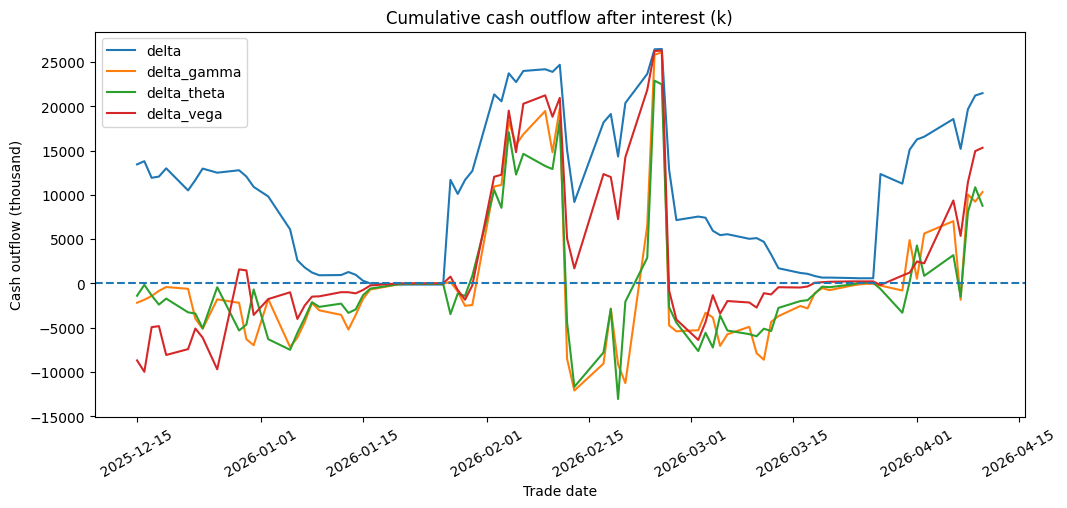

In [14]:
plt.figure(figsize=(12, 5))

for strategy_name, sub in combined_history_df.groupby("strategy"):
    sub = sub.sort_values("trade_date")
    plt.plot(
        sub["trade_date"],
        sub["cumulative_cash_outflow_after_interest"] / 1000.0,
        label=strategy_name,
    )

plt.axhline(0.0, linestyle="--")
plt.title("Cumulative cash outflow after interest (k)")
plt.xlabel("Trade date")
plt.ylabel("Cash outflow (thousand)")
plt.legend()
plt.xticks(rotation=30)
plt.show()


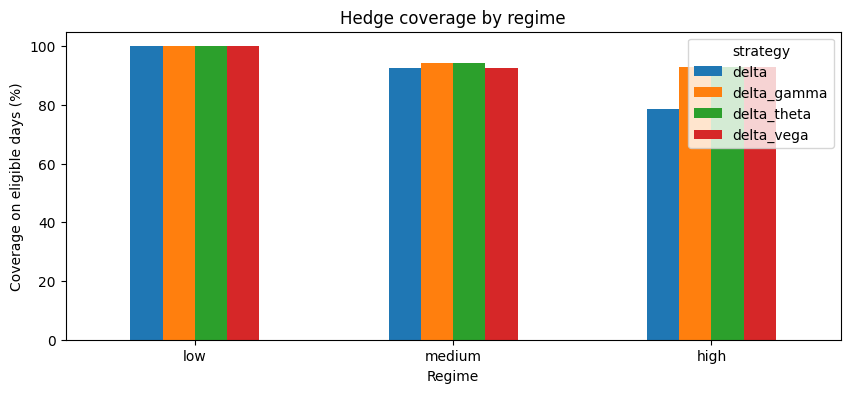

/var/folders/zr/hq_q97d52l1ck8p_4myglv4r0000gn/T/ipykernel_31923/1876050143.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


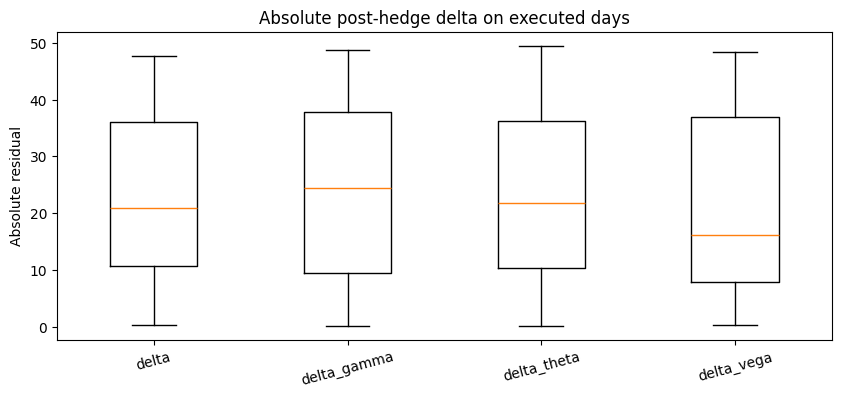

/var/folders/zr/hq_q97d52l1ck8p_4myglv4r0000gn/T/ipykernel_31923/1876050143.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


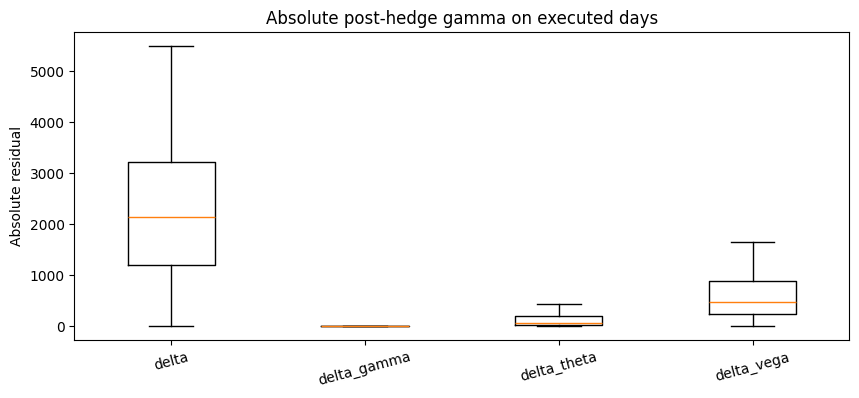

/var/folders/zr/hq_q97d52l1ck8p_4myglv4r0000gn/T/ipykernel_31923/1876050143.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


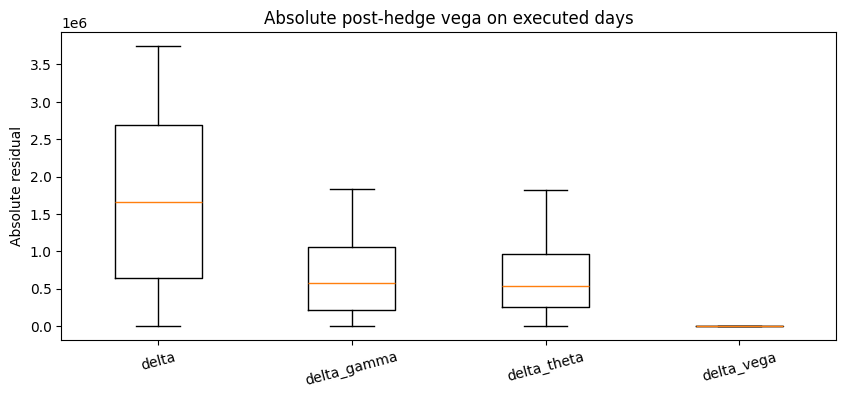

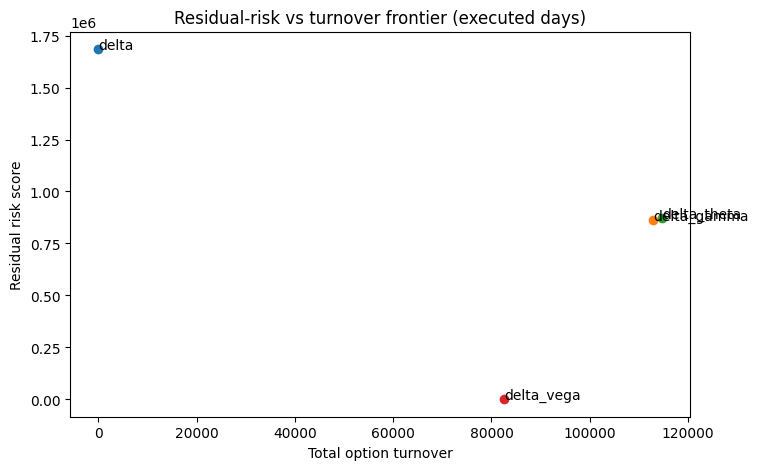

In [15]:
coverage_plot_df = build_hedge_coverage_table(combined_history_df)
coverage_pivot = coverage_plot_df.pivot(index="regime", columns="strategy", values="hedge_coverage_pct")
coverage_pivot = coverage_pivot.reindex(index=["low", "medium", "high"])
coverage_pivot.plot(kind="bar", figsize=(10, 4))
plt.title("Hedge coverage by regime")
plt.xlabel("Regime")
plt.ylabel("Coverage on eligible days (%)")
plt.xticks(rotation=0)
plt.show()

executed_history_df = hedge_executed_days_only(combined_history_df)

greeks_to_plot = [
    ("post_delta", "Absolute post-hedge delta on executed days"),
    ("post_gamma", "Absolute post-hedge gamma on executed days"),
    ("post_vega", "Absolute post-hedge vega on executed days"),
]

for greek_col, title_text in greeks_to_plot:
    plt.figure(figsize=(10, 4))
    box_data = []
    labels = []
    for strat in sorted(executed_history_df["strategy"].dropna().unique()):
        strat_values = executed_history_df.loc[
            executed_history_df["strategy"] == strat, greek_col
        ].abs().dropna().to_numpy()
        if len(strat_values) > 0:
            box_data.append(strat_values)
            labels.append(strat)

    if len(box_data) > 0:
        plt.boxplot(box_data, labels=labels, showfliers=False)
        plt.title(title_text)
        plt.ylabel("Absolute residual")
        plt.xticks(rotation=15)
        plt.show()

frontier_df = compute_effectiveness_metrics(combined_history_df, sample_view="executed").reset_index()
frontier_df = frontier_df.dropna(subset=["residual_risk_score", "total_option_turnover"])

plt.figure(figsize=(8, 5))
for _, row in frontier_df.iterrows():
    plt.scatter(
        row["total_option_turnover"],
        row["residual_risk_score"],
        label=row["strategy"],
    )

plt.title("Residual-risk vs turnover frontier (executed days)")
plt.xlabel("Total option turnover")
plt.ylabel("Residual risk score")
plt.legend(title="Strategy")
plt.show()


## 13. DGV extension and integration notes

The DGV deep-dive below can now plug into the same **coverage-aware** reporting layer used for the initial four strategies.

### Integration principle
When DGV is appended to the unified comparison table, make sure it exposes the same interpretability fields:

- `regime_evaluation_day`
- `hedge_eligible_day`
- `hedge_executed_day`
- `no_hedge_reason`

That way DGV can be compared fairly not only on residual Greeks, but also on **coverage**, **turnover**, and **feasibility under stress**.


---
## Section 13: Delta-Gamma-Vega (DGV) Deep-Dive

The DGV strategy is the most advanced contribution of this notebook. It solves a
two-leg hedge simultaneously targeting delta, gamma, and vega neutrality using a
discrete linear programming approximation.

### Key design choices
- **Two hedge legs**: one short-dated (7–14 DTE) and one longer-dated (60–90 DTE) option
- **Rolling base cycles**: the 30-DTE base position is rolled every month
- **Inventory cap**: gross option inventory capped at 3,000 contracts to maintain
  a controlled, presentation-realistic hedge book
- **Trade-off**: tighter inventory caps slightly reduce hedge precision (higher residual
  Greeks) but produce a more defensible, interpretable book for academic purposes


## 1. DGV-specific inputs

This section **reuses the same dataset, regime table, and persistent option panel**
that were already built above. Only the additional DGV-specific search, stability,
and inventory-control parameters are defined here.


In [16]:
# ---------------------------------------------------
# Reuse shared sample and base settings from above
# ---------------------------------------------------
N_UNDERLYING_SHARES = INITIAL_UNDERLYING_SHARES
CONTRACT_MULTIPLIER = CONTRACT_MULTIPLIER
BASE_OPTION_TYPE = BASE_OPTION_TYPE
BASE_POSITION_SIGN = BASE_POSITION_SIGN
TARGET_ENTRY_DTE = TARGET_ENTRY_DTE

# ---------------------------------------------------
# DGV hedge settings
# ---------------------------------------------------
OPTION_SEARCH_RADIUS = 2
STOCK_ROUND_LOT = 100

# Hard position / trade caps
MAX_ABS_OPTION_TRADE = 3000
MAX_ABS_STOCK_POSITION = 150_000
MAX_GROSS_OPTION_CONTRACTS = 5000

SHORT_HEDGE_DTE_RANGE = (7, 14)
LONG_HEDGE_DTE_RANGE = (60, 90)
MAX_NEW_CANDIDATES_PER_BUCKET = 12
CONDITION_NUMBER_LIMIT = 50000

# Loss weights for residual Greeks after actual trade selection
DELTA_WEIGHT = 1.0
GAMMA_WEIGHT = 1.0
VEGA_WEIGHT = 1.0

# Penalties to keep actual trades near theoretical trades and discourage inventory build-up
QUANTITY_PENALTY = 0.05
TURNOVER_PENALTY = 0.01
INVENTORY_PENALTY_WEIGHT = 0.02

TRADING_DAYS_PER_YEAR = 252
USE_DAILY_RISK_FREE_RATE_FOR_CASH = USE_DAILY_RISK_FREE_RATE_FOR_CASH
MANUAL_CASH_RATE = MANUAL_CASH_RATE

EPS = 1e-12

BASE_CONTRACTS = int(BASE_POSITION_SIGN * (N_UNDERLYING_SHARES / CONTRACT_MULTIPLIER))
print("Base option contracts per cycle:", BASE_CONTRACTS)


Base option contracts per cycle: -1000


## 2. Reuse the already-loaded synthetic market dataset

No data is reloaded here. We simply point to the shared objects created earlier
so the DGV section and the baseline strategies operate on the same market inputs.


In [17]:
stock_df = dataset["stock_history"].copy()
vix_df = dataset["vix_history"].copy()
rates_df = dataset["risk_free_history"].copy()

print("Shared merged daily inputs shape:", merged_df.shape)
print("Shared persistent option panel shape:", panel_df.shape)

display(merged_df.head())
display(panel_df.head())


Shared merged daily inputs shape: (80, 12)
Shared persistent option panel shape: (623642, 17)


,date,open,high,low,close,volume,vix_close,risk_free_rate_pct,risk_free_rate,dividend_yield,realized_vol_21d,base_iv
0,2025-12-15,280.149994,280.149994,272.839996,274.109985,50409100,16.500000,3.538,0.03538,0.005,NaN,0.1650
1,2025-12-16,272.820007,275.500000,271.790009,274.609985,37648600,16.480000,3.545,0.03545,0.005,NaN,0.1648
2,2025-12-17,275.010010,276.160004,271.640015,271.839996,50138700,17.620001,3.543,0.03543,0.005,NaN,0.1762
3,2025-12-18,273.609985,273.630005,266.950012,272.190002,51630700,16.870001,3.522,0.03522,0.005,NaN,0.1687
4,2025-12-19,272.149994,274.600006,269.899994,273.670013,144632000,14.910000,3.522,0.03522,0.005,NaN,0.1491


,trade_date,contract_id,expiry,dte,strike,option_type,spot,risk_free_rate,dividend_yield,base_iv,synthetic_iv,theoretical_price,delta,gamma,vega,theta,rho
0,2025-12-15,2025-12-22|210.0|call,2025-12-22,7,210.0,call,274.109985,0.03538,0.005,0.165,0.176075,64.226143,0.999904,4.796082e-28,1.216857e-25,-6.054342,4.024666
1,2025-12-15,2025-12-22|220.0|call,2025-12-22,7,220.0,call,274.109985,0.03538,0.005,0.165,0.173800,54.232926,0.999904,3.244323e-20,8.125090e-18,-6.407902,4.216316
2,2025-12-15,2025-12-22|230.0|call,2025-12-22,7,230.0,call,274.109985,0.03538,0.005,0.165,0.171625,44.239709,0.999904,6.871268e-14,1.699314e-11,-6.761462,4.407967
3,2025-12-15,2025-12-22|240.0|call,2025-12-22,7,240.0,call,274.109985,0.03538,0.005,0.165,0.169544,34.246492,0.999904,5.570502e-09,1.360915e-06,-7.115028,4.599618
4,2025-12-15,2025-12-22|250.0|call,2025-12-22,7,250.0,call,274.109985,0.03538,0.005,0.165,0.167547,24.253319,0.999873,2.064696e-05,4.984801e-03,-7.490097,4.791104


## 3. Reuse the persistent option panel

The DGV section below uses the **same `panel_df`** and `regime_df` that were built
earlier. This avoids rebuilding the contract panel a second time and guarantees that
all strategies are compared on exactly the same repriced contract universe.


In [18]:
assert "panel_df" in globals(), "Run the persistent panel build section first."
assert "regime_df" in globals(), "Run the regime table section first."

print("Using shared persistent option panel.")
print("Unique trade dates:", panel_df["trade_date"].nunique())
print("Unique contracts in master panel:", panel_df["contract_id"].nunique())


Using shared persistent option panel.
Unique trade dates: 80
Unique contracts in master panel: 9304


## 4. Advanced rebalancing logic for the delta gamma vega strategy

This section introduces the more advanced hedge construction logic used for the delta gamma vega framework. Unlike the simpler strategies that rely on a single hedge option plus stock, this approach searches across both short dated and longer dated option candidates and jointly determines a two option plus stock rebalance that reduces residual delta, gamma, and vega exposure together.

A key idea here is that the rebalance is not chosen only by solving the theoretical Greek neutral equations. The framework also checks practical considerations such as contract availability, conditioning of the hedge system, trade size limits, turnover, and resulting inventory after rebalancing. This makes the selected hedge more realistic and more stable for repeated daily use inside the backtest. 

Overall, this block forms the core optimisation layer for the multi Greek hedge. It allows the notebook to move beyond single Greek neutralisation and evaluate whether a richer hedge structure can deliver better residual risk control while still remaining implementable under realistic portfolio and trading constraints. 

Helper functions

These helpers:
- choose the day-1 ATM base contract
- compute portfolio Greeks using option contracts and stock shares
- build a daily hedge universe from:
  - currently held hedge contracts
  - fresh short-dated candidates
  - fresh longer-dated candidates
- solve the continuous theoretical DGV hedge
- convert it into an actual discrete trade under conditioning and inventory caps


In [19]:
def choose_initial_atm_contract(day_panel, target_dte=30, option_type="call"):
    df = day_panel.loc[day_panel["option_type"] == option_type].copy()
    df["atm_distance"] = (df["strike"] - df["spot"]).abs()
    df["dte_distance"] = (df["dte"] - target_dte).abs()

    chosen = (
        df.sort_values(["atm_distance", "dte_distance", "expiry", "strike"])
        .iloc[0]
    )
    return chosen


def clean_position_book(position_book, day_panel):
    live_ids = set(day_panel["contract_id"].unique())
    cleaned = {
        cid: qty
        for cid, qty in position_book.items()
        if (cid in live_ids) and (abs(qty) > EPS)
    }
    return cleaned


def round_to_lot(x, lot_size=100):
    if not np.isfinite(x):
        return 0.0
    return float(np.round(x / lot_size) * lot_size)


def portfolio_snapshot(day_panel, option_positions, stock_position=0.0, contract_multiplier=100):
    df = day_panel.set_index("contract_id")

    rows = []
    total_delta = float(stock_position)
    total_gamma = 0.0
    total_vega = 0.0
    total_theta = 0.0
    total_option_value = 0.0

    for cid, qty_contracts in option_positions.items():
        if cid not in df.index:
            continue

        row = df.loc[cid]
        qty_shares_equiv = qty_contracts * contract_multiplier

        pos_delta = qty_shares_equiv * float(row["delta"])
        pos_gamma = qty_shares_equiv * float(row["gamma"])
        pos_vega = qty_shares_equiv * float(row["vega"])
        pos_theta = qty_shares_equiv * float(row["theta"])
        pos_value = qty_shares_equiv * float(row["theoretical_price"])

        rows.append(
            {
                "contract_id": cid,
                "quantity_contracts": qty_contracts,
                "quantity_shares_equiv": qty_shares_equiv,
                "price_per_share": float(row["theoretical_price"]),
                "delta_per_share": float(row["delta"]),
                "gamma_per_share": float(row["gamma"]),
                "vega_per_share": float(row["vega"]),
                "theta_per_share": float(row["theta"]),
                "position_delta": pos_delta,
                "position_gamma": pos_gamma,
                "position_vega": pos_vega,
                "position_theta": pos_theta,
                "position_value": pos_value,
            }
        )

        total_delta += pos_delta
        total_gamma += pos_gamma
        total_vega += pos_vega
        total_theta += pos_theta
        total_option_value += pos_value

    details = pd.DataFrame(rows)

    summary = {
        "stock_position_shares": float(stock_position),
        "option_value": float(total_option_value),
        "total_delta": float(total_delta),
        "total_gamma": float(total_gamma),
        "total_vega": float(total_vega),
        "total_theta": float(total_theta),
    }
    return summary, details


def select_current_hedge_candidates(
    day_panel,
    option_positions,
    exclude_contract_ids=None,
    short_long_split_dte=30,
):
    if exclude_contract_ids is None:
        exclude_contract_ids = set()

    held_ids = [
        cid
        for cid, qty in option_positions.items()
        if (abs(qty) > EPS) and (cid not in exclude_contract_ids)
    ]

    if not held_ids:
        return pd.DataFrame(), pd.DataFrame()

    held = day_panel.loc[day_panel["contract_id"].isin(held_ids)].copy()
    if len(held) == 0:
        return pd.DataFrame(), pd.DataFrame()

    held = held.replace([np.inf, -np.inf], np.nan)
    held = held.dropna(subset=[col for col in ["dte", "gamma", "vega", "delta", "theoretical_price"] if col in held.columns])
    if len(held) == 0:
        return pd.DataFrame(), pd.DataFrame()

    held["candidate_score"] = -1.0

    short_candidates = held.loc[held["dte"] <= short_long_split_dte].copy()
    long_candidates = held.loc[held["dte"] > short_long_split_dte].copy()

    return short_candidates.reset_index(drop=True), long_candidates.reset_index(drop=True)


def select_bucket_candidates(day_panel, dte_range, max_candidates=6, exclude_contract_ids=None):
    if exclude_contract_ids is None:
        exclude_contract_ids = set()

    lower_dte, upper_dte = dte_range

    df = day_panel.copy()
    df = df.loc[~df["contract_id"].isin(exclude_contract_ids)].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[col for col in ["dte", "strike", "spot", "gamma", "vega", "delta", "theoretical_price"] if col in df.columns])
    df = df.loc[df["dte"].between(lower_dte, upper_dte)].copy()
    df = df.loc[(df["gamma"].abs() > 1e-12) & (df["vega"].abs() > 1e-12)].copy()

    if len(df) == 0:
        return df.reset_index(drop=True)

    target_dte = 0.5 * (lower_dte + upper_dte)
    df["atm_score"] = np.abs(np.log(df["strike"] / df["spot"]))
    df["dte_score"] = np.abs(df["dte"] - target_dte) / 365.0
    df["candidate_score"] = df["atm_score"] + 0.50 * df["dte_score"]

    return (
        df.sort_values(["candidate_score", "expiry", "option_type", "strike"])
        .head(max_candidates)
        .reset_index(drop=True)
    )


def combine_candidate_frames(*frames):
    usable_frames = [frame.copy() for frame in frames if frame is not None and len(frame) > 0]
    if not usable_frames:
        return pd.DataFrame()

    combined = pd.concat(usable_frames, ignore_index=True)
    if "candidate_score" not in combined.columns:
        combined["candidate_score"] = 0.0
    combined["candidate_score"] = combined["candidate_score"].fillna(-1.0)
    combined = combined.replace([np.inf, -np.inf], np.nan)
    combined = combined.dropna(subset=[col for col in ["gamma", "vega", "delta", "theoretical_price", "candidate_score"] if col in combined.columns])

    if len(combined) == 0:
        return combined.reset_index(drop=True)

    return (
        combined
        .drop_duplicates(subset=["contract_id"], keep="first")
        .sort_values(["candidate_score", "expiry", "option_type", "strike"])
        .reset_index(drop=True)
    )


def apply_option_trades(option_positions, option_trade_map):
    updated = {
        cid: float(qty)
        for cid, qty in option_positions.items()
        if abs(qty) > EPS
    }

    for cid, trade_qty in option_trade_map.items():
        updated[cid] = updated.get(cid, 0.0) + float(trade_qty)

    return {
        cid: qty
        for cid, qty in updated.items()
        if abs(qty) > EPS
    }


def gross_option_contracts(option_positions):
    return float(sum(abs(qty) for qty in option_positions.values()))


def hedge_objective(
    residual_delta,
    residual_gamma,
    residual_vega,
    delta_scale,
    gamma_scale,
    vega_scale,
    q_a_actual,
    q_b_actual,
    q_stock_actual,
    q_a_theory,
    q_b_theory,
    q_stock_theory,
    post_option_positions,
    post_stock_position,
    quantity_penalty=0.05,
    turnover_penalty=0.01,
    inventory_penalty_weight=0.02,
):
    greek_loss = (
        DELTA_WEIGHT * (residual_delta / max(delta_scale, 1.0)) ** 2
        + GAMMA_WEIGHT * (residual_gamma / max(gamma_scale, 1e-8)) ** 2
        + VEGA_WEIGHT * (residual_vega / max(vega_scale, 1e-8)) ** 2
    )

    quantity_gap = (
        (q_a_actual - q_a_theory) ** 2
        + (q_b_actual - q_b_theory) ** 2
        + ((q_stock_actual - q_stock_theory) / max(STOCK_ROUND_LOT, 1.0)) ** 2
    )

    turnover = (
        abs(q_a_actual)
        + abs(q_b_actual)
        + abs(q_stock_actual) / max(STOCK_ROUND_LOT, 1.0)
    )

    inventory_penalty = (
        abs(post_stock_position) / max(STOCK_ROUND_LOT, 1.0)
        + sum(abs(qty) for qty in post_option_positions.values())
    )

    return (
        greek_loss
        + quantity_penalty * quantity_gap
        + turnover_penalty * turnover
        + inventory_penalty_weight * inventory_penalty
    )


def find_best_daily_rebalance(
    day_panel,
    option_positions,
    stock_position,
    exclude_contract_ids=None,
    max_new_candidates_per_bucket=6,
    short_dte_range=(14, 21),
    long_dte_range=(45, 60),
    option_search_radius=2,
    condition_number_limit=500,
    quantity_penalty=0.05,
    turnover_penalty=0.01,
    inventory_penalty_weight=0.02,
    max_abs_option_trade=3000,
    max_abs_stock_position=150_000,
    max_gross_option_contracts=5000,
    contract_multiplier=100,
):
    if exclude_contract_ids is None:
        exclude_contract_ids = set()

    pre_summary, _ = portfolio_snapshot(
        day_panel=day_panel,
        option_positions=option_positions,
        stock_position=stock_position,
        contract_multiplier=contract_multiplier,
    )

    short_long_split_dte = 0.5 * (short_dte_range[1] + long_dte_range[0])

    current_short_candidates, current_long_candidates = select_current_hedge_candidates(
        day_panel=day_panel,
        option_positions=option_positions,
        exclude_contract_ids=exclude_contract_ids,
        short_long_split_dte=short_long_split_dte,
    )

    fresh_short_candidates = select_bucket_candidates(
        day_panel=day_panel,
        dte_range=short_dte_range,
        max_candidates=max_new_candidates_per_bucket,
        exclude_contract_ids=exclude_contract_ids,
    )
    fresh_long_candidates = select_bucket_candidates(
        day_panel=day_panel,
        dte_range=long_dte_range,
        max_candidates=max_new_candidates_per_bucket,
        exclude_contract_ids=exclude_contract_ids,
    )

    short_candidates = combine_candidate_frames(current_short_candidates, fresh_short_candidates)
    long_candidates = combine_candidate_frames(current_long_candidates, fresh_long_candidates)

    if (len(short_candidates) == 0) or (len(long_candidates) == 0):
        return None

    best = None
    short_rows = list(short_candidates.to_dict("records"))
    long_rows = list(long_candidates.to_dict("records"))

    delta_scale = max(abs(pre_summary["total_delta"]), N_UNDERLYING_SHARES, 1.0)
    gamma_scale = max(abs(pre_summary["total_gamma"]), 1.0)
    vega_scale = max(abs(pre_summary["total_vega"]), 1.0)

    for row_a in short_rows:
        for row_b in long_rows:
            if row_a["contract_id"] == row_b["contract_id"]:
                continue

            A = np.array(
                [
                    [contract_multiplier * row_a["gamma"], contract_multiplier * row_b["gamma"]],
                    [contract_multiplier * row_a["vega"], contract_multiplier * row_b["vega"]],
                ],
                dtype=float,
            )

            if not np.all(np.isfinite(A)):
                continue

            try:
                cond_number = np.linalg.cond(A)
            except np.linalg.LinAlgError:
                continue
            if (not np.isfinite(cond_number)) or (cond_number > condition_number_limit):
                continue

            b = -np.array(
                [pre_summary["total_gamma"], pre_summary["total_vega"]],
                dtype=float,
            )

            try:
                q_theory = np.linalg.solve(A, b)
            except np.linalg.LinAlgError:
                continue
            if not np.all(np.isfinite(q_theory)):
                continue

            q_a_theory = float(np.clip(q_theory[0], -max_abs_option_trade, max_abs_option_trade))
            q_b_theory = float(np.clip(q_theory[1], -max_abs_option_trade, max_abs_option_trade))

            q_stock_theory = -(
                pre_summary["total_delta"]
                + contract_multiplier * row_a["delta"] * q_a_theory
                + contract_multiplier * row_b["delta"] * q_b_theory
            )
            post_stock_theory = float(
                np.clip(stock_position + q_stock_theory, -max_abs_stock_position, max_abs_stock_position)
            )
            q_stock_theory = float(post_stock_theory - stock_position)
            if not all(np.isfinite(v) for v in [q_a_theory, q_b_theory, q_stock_theory]):
                continue

            q_a_center = int(np.round(q_a_theory))
            q_b_center = int(np.round(q_b_theory))

            q_a_min = max(-max_abs_option_trade, q_a_center - option_search_radius)
            q_a_max = min(max_abs_option_trade, q_a_center + option_search_radius)
            q_b_min = max(-max_abs_option_trade, q_b_center - option_search_radius)
            q_b_max = min(max_abs_option_trade, q_b_center + option_search_radius)

            q_a_grid = range(q_a_min, q_a_max + 1)
            q_b_grid = range(q_b_min, q_b_max + 1)

            for q_a_actual in q_a_grid:
                for q_b_actual in q_b_grid:
                    raw_stock_trade = -(
                        pre_summary["total_delta"]
                        + contract_multiplier * row_a["delta"] * q_a_actual
                        + contract_multiplier * row_b["delta"] * q_b_actual
                    )
                    post_stock_position = round_to_lot(
                        np.clip(
                            stock_position + raw_stock_trade,
                            -max_abs_stock_position,
                            max_abs_stock_position,
                        ),
                        lot_size=STOCK_ROUND_LOT,
                    )
                    post_stock_position = float(
                        np.clip(post_stock_position, -max_abs_stock_position, max_abs_stock_position)
                    )
                    q_stock_actual = float(post_stock_position - stock_position)

                    post_option_positions = apply_option_trades(
                        option_positions,
                        {
                            row_a["contract_id"]: float(q_a_actual),
                            row_b["contract_id"]: float(q_b_actual),
                        },
                    )
                    gross_contracts = gross_option_contracts(post_option_positions)
                    if gross_contracts > max_gross_option_contracts:
                        continue

                    residual_delta = (
                        pre_summary["total_delta"]
                        + contract_multiplier * row_a["delta"] * q_a_actual
                        + contract_multiplier * row_b["delta"] * q_b_actual
                        + q_stock_actual
                    )
                    residual_gamma = (
                        pre_summary["total_gamma"]
                        + contract_multiplier * row_a["gamma"] * q_a_actual
                        + contract_multiplier * row_b["gamma"] * q_b_actual
                    )
                    residual_vega = (
                        pre_summary["total_vega"]
                        + contract_multiplier * row_a["vega"] * q_a_actual
                        + contract_multiplier * row_b["vega"] * q_b_actual
                    )
                    if not all(np.isfinite(v) for v in [residual_delta, residual_gamma, residual_vega, post_stock_position]):
                        continue

                    objective = hedge_objective(
                        residual_delta=residual_delta,
                        residual_gamma=residual_gamma,
                        residual_vega=residual_vega,
                        delta_scale=delta_scale,
                        gamma_scale=gamma_scale,
                        vega_scale=vega_scale,
                        q_a_actual=q_a_actual,
                        q_b_actual=q_b_actual,
                        q_stock_actual=q_stock_actual,
                        q_a_theory=q_a_theory,
                        q_b_theory=q_b_theory,
                        q_stock_theory=q_stock_theory,
                        post_option_positions=post_option_positions,
                        post_stock_position=post_stock_position,
                        quantity_penalty=quantity_penalty,
                        turnover_penalty=turnover_penalty,
                        inventory_penalty_weight=inventory_penalty_weight,
                    )
                    if not np.isfinite(objective):
                        continue

                    candidate = {
                        "contract_a": row_a["contract_id"],
                        "contract_b": row_b["contract_id"],
                        "row_a": row_a,
                        "row_b": row_b,
                        "q_a_theory": q_a_theory,
                        "q_b_theory": q_b_theory,
                        "q_stock_theory": float(q_stock_theory),
                        "q_a_actual": float(q_a_actual),
                        "q_b_actual": float(q_b_actual),
                        "q_stock_actual": float(q_stock_actual),
                        "post_stock_position": float(post_stock_position),
                        "post_option_positions": post_option_positions,
                        "gross_option_contracts_after_trade": float(gross_contracts),
                        "post_delta_residual": float(residual_delta),
                        "post_gamma_residual": float(residual_gamma),
                        "post_vega_residual": float(residual_vega),
                        "condition_number": float(cond_number),
                        "objective": float(objective),
                    }

                    if (best is None) or (candidate["objective"] < best["objective"]):
                        best = candidate

    return best


## 5. Delta gamma vega rolling hedge simulation

This section runs the full daily simulation for the delta gamma vega strategy using the shared persistent option panel and the rolling base framework. The portfolio begins with a short near at the money call exposure and is then rebalanced through the full sample, rather than stopping at the first expiry. Whenever the active base contract expires or disappears from the live panel, the existing book is liquidated, a fresh base contract is entered, and the hedge continues seamlessly into the next cycle.

The simulation records the portfolio state before and after each rebalance, the selected hedge instruments, the theoretical and actual trade sizes, and the resulting cash flows after interest. This makes the output suitable not only for performance comparison, but also for understanding how the strategy behaves operationally across time, across base roll cycles, and under different market conditions.

Overall, this block produces the main daily history and trade log for the DGV strategy. These outputs form the basis for later analysis of hedge effectiveness, turnover, residual Greek exposure, and cumulative cash outflow, while preserving a realistic rolling hedge structure throughout the sample.

In [20]:
all_dates = [pd.Timestamp(trade_date) for trade_date in sorted(panel_df["trade_date"].unique())]
first_date = all_dates[0]

day1_panel = panel_df.loc[panel_df["trade_date"] == first_date].copy()

preview_contract = choose_initial_atm_contract(
    day_panel=day1_panel,
    target_dte=TARGET_ENTRY_DTE,
    option_type=BASE_OPTION_TYPE,
)

print("Chosen base contract on day 1:")
display(
    preview_contract.to_frame().T[
        [
            "trade_date", "expiry", "dte", "strike", "option_type",
            "contract_id", "theoretical_price", "delta", "gamma", "vega"
        ]
    ]
)
print("Simulation rebalances through latest available trade date:", all_dates[-1].date())

current_base_contract_id = None
current_base_expiry = None
base_cycle_index = 0

# Position book stores quantities in option contracts
option_positions = {}
stock_position = 0.0

cumulative_cash_after_interest = 0.0

history_rows = []
trade_log_rows = []

for trade_date in all_dates:
    day_panel = panel_df.loc[panel_df["trade_date"] == trade_date].copy()
    active_contract_ids = set(day_panel["contract_id"])
    spot_t = float(day_panel["spot"].iloc[0])
    r_cash_t = float(day_panel["risk_free_rate"].iloc[0]) if USE_DAILY_RISK_FREE_RATE_FOR_CASH else MANUAL_CASH_RATE

    option_positions = clean_position_book(option_positions, day_panel)

    base_trade_contracts = 0.0
    base_trade_cashflow = 0.0
    hedge_option_trade_cashflow = 0.0
    stock_trade_cashflow = 0.0
    option_liquidation_cashflow = 0.0
    stock_liquidation_cashflow = 0.0
    liquidation_applied = False
    is_base_entry_day = False

    q_a_actual = 0.0
    q_b_actual = 0.0
    q_stock_actual = 0.0
    q_a_theory = np.nan
    q_b_theory = np.nan
    q_stock_theory = np.nan
    contract_a = None
    contract_b = None
    condition_number = np.nan
    objective = np.nan
    gross_option_contracts_after_trade = gross_option_contracts(option_positions)

    is_base_expiry_day = (
        current_base_contract_id is not None
        and (
            trade_date >= current_base_expiry
            or current_base_contract_id not in active_contract_ids
        )
    )

    if is_base_expiry_day:
        liquidation_applied = True

        for cid, qty in list(option_positions.items()):
            if cid not in active_contract_ids:
                continue
            row = day_panel.loc[day_panel["contract_id"] == cid].iloc[0]
            option_liquidation_cashflow += (-qty) * CONTRACT_MULTIPLIER * float(row["theoretical_price"])

        stock_liquidation_cashflow = (-stock_position) * spot_t
        option_positions = {}
        stock_position = 0.0
        gross_option_contracts_after_trade = 0.0

    if current_base_contract_id is None or liquidation_applied:
        entry_contract = choose_initial_atm_contract(
            day_panel=day_panel,
            target_dte=TARGET_ENTRY_DTE,
            option_type=BASE_OPTION_TYPE,
        )

        current_base_contract_id = entry_contract["contract_id"]
        current_base_expiry = pd.Timestamp(entry_contract["expiry"])
        base_cycle_index += 1

        option_positions = {current_base_contract_id: float(BASE_CONTRACTS)}
        base_trade_contracts = float(BASE_CONTRACTS)
        base_trade_cashflow = base_trade_contracts * CONTRACT_MULTIPLIER * float(entry_contract["theoretical_price"])
        is_base_entry_day = True

    base_row = day_panel.loc[day_panel["contract_id"] == current_base_contract_id].iloc[0]

    pre_summary, pre_details = portfolio_snapshot(
        day_panel=day_panel,
        option_positions=option_positions,
        stock_position=stock_position,
        contract_multiplier=CONTRACT_MULTIPLIER,
    )

    rebalance = find_best_daily_rebalance(
        day_panel=day_panel,
        option_positions=option_positions,
        stock_position=stock_position,
        exclude_contract_ids={current_base_contract_id},
        max_new_candidates_per_bucket=MAX_NEW_CANDIDATES_PER_BUCKET,
        short_dte_range=SHORT_HEDGE_DTE_RANGE,
        long_dte_range=LONG_HEDGE_DTE_RANGE,
        option_search_radius=OPTION_SEARCH_RADIUS,
        condition_number_limit=CONDITION_NUMBER_LIMIT,
        quantity_penalty=QUANTITY_PENALTY,
        turnover_penalty=TURNOVER_PENALTY,
        inventory_penalty_weight=INVENTORY_PENALTY_WEIGHT,
        max_abs_option_trade=MAX_ABS_OPTION_TRADE,
        max_abs_stock_position=MAX_ABS_STOCK_POSITION,
        max_gross_option_contracts=MAX_GROSS_OPTION_CONTRACTS,
        contract_multiplier=CONTRACT_MULTIPLIER,
    )

    if rebalance is not None:
        contract_a = rebalance["contract_a"]
        contract_b = rebalance["contract_b"]

        q_a_theory = rebalance["q_a_theory"]
        q_b_theory = rebalance["q_b_theory"]
        q_stock_theory = rebalance["q_stock_theory"]

        q_a_actual = rebalance["q_a_actual"]
        q_b_actual = rebalance["q_b_actual"]
        q_stock_actual = rebalance["q_stock_actual"]

        condition_number = rebalance["condition_number"]
        objective = rebalance["objective"]

        row_a = day_panel.loc[day_panel["contract_id"] == contract_a].iloc[0]
        row_b = day_panel.loc[day_panel["contract_id"] == contract_b].iloc[0]

        hedge_option_trade_cashflow = (
            q_a_actual * CONTRACT_MULTIPLIER * float(row_a["theoretical_price"])
            + q_b_actual * CONTRACT_MULTIPLIER * float(row_b["theoretical_price"])
        )
        stock_trade_cashflow = q_stock_actual * spot_t

        option_positions = apply_option_trades(
            option_positions,
            {
                contract_a: q_a_actual,
                contract_b: q_b_actual,
            },
        )
        stock_position = float(rebalance["post_stock_position"])
        gross_option_contracts_after_trade = gross_option_contracts(option_positions)

    total_trade_cashflow = (
        base_trade_cashflow
        + hedge_option_trade_cashflow
        + stock_trade_cashflow
        + option_liquidation_cashflow
        + stock_liquidation_cashflow
    )
    cumulative_cash_before_interest = cumulative_cash_after_interest + total_trade_cashflow
    interest_cost = cumulative_cash_before_interest * (r_cash_t / TRADING_DAYS_PER_YEAR)
    cumulative_cash_after_interest = cumulative_cash_before_interest + interest_cost

    post_summary, post_details = portfolio_snapshot(
        day_panel=day_panel,
        option_positions=option_positions,
        stock_position=stock_position,
        contract_multiplier=CONTRACT_MULTIPLIER,
    )

    history_rows.append(
        {
            "trade_date": trade_date,
            "spot": spot_t,
            "risk_free_rate": r_cash_t,
            "base_cycle_index": int(base_cycle_index),
            "is_base_entry_day": bool(is_base_entry_day),
            "is_base_expiry_day": bool(is_base_expiry_day),
            "liquidation_applied": bool(liquidation_applied),

            "base_contract_id": current_base_contract_id,
            "base_expiry": current_base_expiry.date(),
            "base_dte": float(base_row["dte"]),
            "base_strike": float(base_row["strike"]),
            "base_option_type": BASE_OPTION_TYPE,
            "base_option_price_per_share": float(base_row["theoretical_price"]),
            "base_delta_per_share": float(base_row["delta"]),
            "base_gamma_per_share": float(base_row["gamma"]),
            "base_vega_per_share": float(base_row["vega"]),
            "base_contracts_held": float(option_positions.get(current_base_contract_id, 0.0)),

            "pre_delta": float(pre_summary["total_delta"]),
            "pre_gamma": float(pre_summary["total_gamma"]),
            "pre_vega": float(pre_summary["total_vega"]),

            "contract_a": contract_a,
            "contract_b": contract_b,
            "q_a_theory_contracts": q_a_theory,
            "q_b_theory_contracts": q_b_theory,
            "q_stock_theory_shares": q_stock_theory,
            "q_a_actual_contracts": q_a_actual,
            "q_b_actual_contracts": q_b_actual,
            "q_stock_actual_shares": q_stock_actual,

            "post_delta": float(post_summary["total_delta"]),
            "post_gamma": float(post_summary["total_gamma"]),
            "post_vega": float(post_summary["total_vega"]),

            "stock_position_after_trade": float(stock_position),
            "gross_option_contracts_after_trade": float(gross_option_contracts_after_trade),
            "n_option_positions_after_trade": int(len(option_positions)),

            "base_trade_cashflow": float(base_trade_cashflow),
            "hedge_option_trade_cashflow": float(hedge_option_trade_cashflow),
            "stock_trade_cashflow": float(stock_trade_cashflow),
            "option_liquidation_cashflow": float(option_liquidation_cashflow),
            "stock_liquidation_cashflow": float(stock_liquidation_cashflow),
            "total_trade_cashflow": float(total_trade_cashflow),
            "cumulative_cash_outflow_before_interest": float(cumulative_cash_before_interest),
            "interest_cost": float(interest_cost),
            "cumulative_cash_outflow_after_interest": float(cumulative_cash_after_interest),

            "base_trade_cashflow_k": float(base_trade_cashflow / 1000.0),
            "hedge_option_trade_cashflow_k": float(hedge_option_trade_cashflow / 1000.0),
            "stock_trade_cashflow_k": float(stock_trade_cashflow / 1000.0),
            "option_liquidation_cashflow_k": float(option_liquidation_cashflow / 1000.0),
            "stock_liquidation_cashflow_k": float(stock_liquidation_cashflow / 1000.0),
            "total_trade_cashflow_k": float(total_trade_cashflow / 1000.0),
            "cumulative_cash_outflow_before_interest_k": float(cumulative_cash_before_interest / 1000.0),
            "interest_cost_k": float(interest_cost / 1000.0),
            "cumulative_cash_outflow_after_interest_k": float(cumulative_cash_after_interest / 1000.0),

            "objective": objective,
            "condition_number": condition_number,
        }
    )

    trade_log_rows.append(
        {
            "trade_date": trade_date,
            "base_cycle_index": int(base_cycle_index),
            "is_base_entry_day": bool(is_base_entry_day),
            "is_base_expiry_day": bool(is_base_expiry_day),
            "liquidation_applied": bool(liquidation_applied),
            "base_trade_contracts": base_trade_contracts,
            "contract_a": contract_a,
            "contract_b": contract_b,
            "q_a_theory_contracts": q_a_theory,
            "q_b_theory_contracts": q_b_theory,
            "q_stock_theory_shares": q_stock_theory,
            "q_a_actual_contracts": q_a_actual,
            "q_b_actual_contracts": q_b_actual,
            "q_stock_actual_shares": q_stock_actual,
            "base_trade_cashflow": base_trade_cashflow,
            "hedge_option_trade_cashflow": hedge_option_trade_cashflow,
            "stock_trade_cashflow": stock_trade_cashflow,
            "option_liquidation_cashflow": option_liquidation_cashflow,
            "stock_liquidation_cashflow": stock_liquidation_cashflow,
            "total_trade_cashflow": total_trade_cashflow,
            "post_delta": post_summary["total_delta"],
            "post_gamma": post_summary["total_gamma"],
            "post_vega": post_summary["total_vega"],
            "gross_option_contracts_after_trade": gross_option_contracts_after_trade,
            "stock_position_after_trade": stock_position,
        }
    )

history_df = pd.DataFrame(history_rows)
trade_log_df = pd.DataFrame(trade_log_rows)

print("Simulation finished.")
print("Simulation end date:", all_dates[-1].date())
print("Base cycles entered:", base_cycle_index)
print("Rows in daily history:", len(history_df))
display(history_df.head())


Chosen base contract on day 1:


,trade_date,expiry,dte,strike,option_type,contract_id,theoretical_price,delta,gamma,vega
790,2025-12-15 00:00:00,2026-01-27 00:00:00,43,275.0,call,2026-01-27|275.0|call,6.267895,0.513417,0.025528,37.489529


Simulation rebalances through latest available trade date: 2026-04-10
Simulation finished.
Simulation end date: 2026-04-10
Base cycles entered: 4
Rows in daily history: 80


,trade_date,spot,risk_free_rate,base_cycle_index,is_base_entry_day,is_base_expiry_day,liquidation_applied,base_contract_id,base_expiry,base_dte,base_strike,base_option_type,base_option_price_per_share,base_delta_per_share,base_gamma_per_share,base_vega_per_share,base_contracts_held,pre_delta,pre_gamma,pre_vega,contract_a,contract_b,q_a_theory_contracts,q_b_theory_contracts,q_stock_theory_shares,q_a_actual_contracts,q_b_actual_contracts,q_stock_actual_shares,post_delta,post_gamma,post_vega,stock_position_after_trade,gross_option_contracts_after_trade,n_option_positions_after_trade,base_trade_cashflow,hedge_option_trade_cashflow,stock_trade_cashflow,option_liquidation_cashflow,stock_liquidation_cashflow,total_trade_cashflow,cumulative_cash_outflow_before_interest,interest_cost,cumulative_cash_outflow_after_interest,base_trade_cashflow_k,hedge_option_trade_cashflow_k,stock_trade_cashflow_k,option_liquidation_cashflow_k,stock_liquidation_cashflow_k,total_trade_cashflow_k,cumulative_cash_outflow_before_interest_k,interest_cost_k,cumulative_cash_outflow_after_interest_k,objective,condition_number
0,2025-12-15,274.109985,0.03538,1,True,False,False,2026-01-27|275.0|call,2026-01-27,43.0,275.0,call,6.267895,0.513417,0.025528,37.489529,-1000.0,-51341.700816,-2552.810581,-3.748953e+06,2025-12-22|270.0|call,2026-03-08|275.0|call,270.582759,660.735698,-4450.165136,270.0,660.0,-4400.0,-33.318706,-4.252927,-4507.165698,-4400.0,1930.0,3,-626789.486212,748220.472626,-1.206084e+06,0.0,0.0,-1.084653e+06,-1.084653e+06,-152.281835,-1.084805e+06,-626.789486,748.220473,-1206.083936,0.0,0.0,-1084.652949,-1084.652949,-0.152282,-1084.805231,49.276630,1187.223410
1,2025-12-16,274.609985,0.03545,1,False,False,False,2026-01-27|275.0|call,2026-01-27,42.0,275.0,call,6.431972,0.525689,0.025798,37.062241,-1000.0,428.807215,-66.771306,-3.677241e+04,2025-12-26|280.0|put,2026-03-06|275.0|put,14.279707,3.160752,784.988599,14.0,3.0,800.0,43.305705,-1.490033,-1223.821154,-3600.0,1947.0,5,0.000000,11117.332998,2.196880e+05,0.0,0.0,2.308053e+05,-8.539999e+05,-120.136101,-8.541200e+05,0.000000,11.117333,219.687988,0.0,0.0,230.805321,-853.999910,-0.120136,-854.120046,39.917936,1470.361418
2,2025-12-17,271.839996,0.03543,1,False,False,False,2026-01-27|275.0|call,2026-01-27,41.0,275.0,call,5.423533,0.457107,0.024515,36.118969,-1000.0,-737.531683,561.398443,1.057047e+05,2025-12-22|270.0|call,2026-03-06|275.0|put,-82.947590,-1.422728,5990.377893,-83.0,-2.0,6000.0,35.501008,-1.367284,-2971.177163,2400.0,1862.0,5,0.000000,-29464.675829,1.631040e+06,0.0,0.0,1.601575e+06,7.474553e+05,105.088649,7.475603e+05,0.000000,-29.464676,1631.039978,0.0,0.0,1601.575302,747.455256,0.105089,747.560345,39.188059,841.124641
3,2025-12-18,272.190002,0.03522,1,False,False,False,2026-01-27|275.0|call,2026-01-27,40.0,275.0,call,5.218692,0.461636,0.025938,35.763502,-1000.0,673.317284,48.163908,-1.903018e+04,2025-12-26|280.0|put,2026-03-06|275.0|put,-19.021453,7.137183,-1956.988265,-19.0,7.0,-2000.0,-37.966531,-0.184012,-668.965340,400.0,1860.0,5,0.000000,-8961.517511,-5.443800e+05,0.0,0.0,-5.533415e+05,1.942188e+05,27.144393,1.942460e+05,0.000000,-8.961518,-544.380005,0.0,0.0,-553.341522,194.218823,0.027144,194.245967,37.751464,1782.209884
4,2025-12-19,273.670013,0.03522,1,False,False,False,2026-01-27|275.0|call,2026-01-27,39.0,275.0,call,5.128220,0.496311,0.029754,35.667702,-1000.0,1230.580437,-423.768017,-7.992728e+04,2025-12-26|270.0|put,2026-03-06|275.0|put,76.796154,-2.219428,527.407352,76.0,-2.0,500.0,-18.548890,-3.982529,153.728319,900.0,1934.0,6,0.000000,4701.345102,1.368350e+05,0.0,0.0,1.415364e+05,3.357823e+05,46.929577,3.358292e+05,0.000000,4.701345,136.835007,0.0,0.0,141.536352,335.782319,0.046930,335.829248,39.727948,1039.198221


## 6. Daily strategy table
 
It keeps the focus on:
- Greeks before rebalance
- theoretical hedge
- actual hedge
- cash flow and cumulative funding cost

In [21]:
daily_strategy_table = history_df[
    [
        "trade_date",
        "base_cycle_index",
        "is_base_entry_day",
        "is_base_expiry_day",
        "spot",
        "base_expiry",
        "base_dte",
        "base_option_price_per_share",
        "base_delta_per_share",
        "base_gamma_per_share",
        "base_vega_per_share",
        "base_contracts_held",
        "pre_delta",
        "pre_gamma",
        "pre_vega",
        "q_a_theory_contracts",
        "q_b_theory_contracts",
        "q_stock_theory_shares",
        "q_a_actual_contracts",
        "q_b_actual_contracts",
        "q_stock_actual_shares",
        "post_delta",
        "post_gamma",
        "post_vega",
        "stock_position_after_trade",
        "gross_option_contracts_after_trade",
        "liquidation_applied",
        "option_liquidation_cashflow_k",
        "stock_liquidation_cashflow_k",
        "total_trade_cashflow_k",
        "cumulative_cash_outflow_before_interest_k",
        "interest_cost_k",
        "cumulative_cash_outflow_after_interest_k",
    ]
].copy()

daily_strategy_table["regime_evaluation_day"] = True
daily_strategy_table["hedge_eligible_day"] = (
    daily_strategy_table["pre_delta"].abs()
    + daily_strategy_table["pre_gamma"].abs()
    + daily_strategy_table["pre_vega"].abs()
) > 1e-8
daily_strategy_table["hedge_executed_day"] = (
    daily_strategy_table["q_a_actual_contracts"].abs()
    + daily_strategy_table["q_b_actual_contracts"].abs()
    + daily_strategy_table["q_stock_actual_shares"].abs()
) > 1e-8

display(daily_strategy_table.head(20))


,trade_date,base_cycle_index,is_base_entry_day,is_base_expiry_day,spot,base_expiry,base_dte,base_option_price_per_share,base_delta_per_share,base_gamma_per_share,base_vega_per_share,base_contracts_held,pre_delta,pre_gamma,pre_vega,q_a_theory_contracts,q_b_theory_contracts,q_stock_theory_shares,q_a_actual_contracts,q_b_actual_contracts,q_stock_actual_shares,post_delta,post_gamma,post_vega,stock_position_after_trade,gross_option_contracts_after_trade,liquidation_applied,option_liquidation_cashflow_k,stock_liquidation_cashflow_k,total_trade_cashflow_k,cumulative_cash_outflow_before_interest_k,interest_cost_k,cumulative_cash_outflow_after_interest_k,regime_evaluation_day,hedge_eligible_day,hedge_executed_day
0,2025-12-15,1,True,False,274.109985,2026-01-27,43.0,6.267895,0.513417,0.025528,37.489529,-1000.0,-51341.700816,-2552.810581,-3.748953e+06,270.582759,660.735698,-4450.165136,270.0,660.0,-4400.0,-33.318706,-4.252927,-4507.165698,-4400.0,1930.0,False,0.0,0.0,-1084.652949,-1084.652949,-0.152282,-1084.805231,True,True,True
1,2025-12-16,1,False,False,274.609985,2026-01-27,42.0,6.431972,0.525689,0.025798,37.062241,-1000.0,428.807215,-66.771306,-3.677241e+04,14.279707,3.160752,784.988599,14.0,3.0,800.0,43.305705,-1.490033,-1223.821154,-3600.0,1947.0,False,0.0,0.0,230.805321,-853.999910,-0.120136,-854.120046,True,True,True
2,2025-12-17,1,False,False,271.839996,2026-01-27,41.0,5.423533,0.457107,0.024515,36.118969,-1000.0,-737.531683,561.398443,1.057047e+05,-82.947590,-1.422728,5990.377893,-83.0,-2.0,6000.0,35.501008,-1.367284,-2971.177163,2400.0,1862.0,False,0.0,0.0,1601.575302,747.455256,0.105089,747.560345,True,True,True
3,2025-12-18,1,False,False,272.190002,2026-01-27,40.0,5.218692,0.461636,0.025938,35.763502,-1000.0,673.317284,48.163908,-1.903018e+04,-19.021453,7.137183,-1956.988265,-19.0,7.0,-2000.0,-37.966531,-0.184012,-668.965340,400.0,1860.0,False,0.0,0.0,-553.341522,194.218823,0.027144,194.245967,True,True,True
4,2025-12-19,1,False,False,273.670013,2026-01-27,39.0,5.128220,0.496311,0.029754,35.667702,-1000.0,1230.580437,-423.768017,-7.992728e+04,76.796154,-2.219428,527.407352,76.0,-2.0,500.0,-18.548890,-3.982529,153.728319,900.0,1934.0,False,0.0,0.0,141.536352,335.782319,0.046930,335.829248,True,True,True
5,2025-12-22,1,False,False,270.970001,2026-01-27,36.0,3.401635,0.404070,0.032103,32.951260,-1000.0,6819.396875,-983.425182,5.327761e+04,108.975006,-35.060416,-942.320299,109.0,-35.0,-900.0,44.128485,0.378769,323.542657,-0.0,2008.0,False,0.0,0.0,-252.937790,82.891459,0.011605,82.903064,True,True,True
6,2025-12-23,1,False,False,272.359985,2026-01-27,35.0,3.884181,0.447039,0.033317,33.336071,-1000.0,-18158.737226,-237.648908,-8.988390e+04,32.012721,9.875012,15357.145613,32.0,10.0,15400.0,49.521932,0.186157,580.867825,15400.0,1863.0,False,0.0,0.0,4214.992138,4297.895202,0.604946,4298.500148,True,True,True
7,2025-12-24,1,False,False,273.809998,2026-01-27,34.0,4.302980,0.493566,0.035321,33.319433,-1000.0,827.036339,-873.942844,-1.079404e+05,151.322347,-8.391531,-12457.116859,151.0,-8.0,-12500.0,-43.779800,-1.040581,1503.860053,2900.0,2006.0,False,0.0,0.0,-3363.141240,935.358907,0.131952,935.490860,True,True,True
8,2025-12-26,1,False,False,273.399994,2026-01-27,32.0,3.987973,0.476556,0.036069,32.226218,-1000.0,2652.203624,-859.165326,-2.485080e+04,154.229716,-32.279173,2684.275198,154.0,-32.0,2700.0,35.523793,-0.730162,1080.746990,5600.0,2128.0,False,0.0,0.0,727.889364,1663.380224,0.233863,1663.614087,True,True,True
9,2025-12-29,1,False,False,273.760010,2026-01-27,29.0,4.095876,0.486835,0.036339,30.756044,-1000.0,2800.476432,-689.192381,-1.019354e+05,109.534181,5.264052,-1316.009975,109.0,5.0,-1300.0,8.149321,-3.878917,-1571.224324,4300.0,2052.0,False,0.0,0.0,-347.084433,1316.529655,0.184837,1316.714491,True,True,True


In [22]:
# DGV will be incorporated into the shared comparison framework below by
# registering `solve_delta_gamma_vega` inside `STRATEGY_SOLVERS` and rerunning
# the common rolling-base backtest engine across all five strategies.


## 7. Hedge quality checks
Ideally the post-rebalance Greeks should be close to zero.  
Because actual trades are discrete, they may not be exactly zero every day.  
On the final base-expiry row, the liquidation step should leave the post-trade Greeks at zero.


In [23]:
quality_view = history_df[
    [
        "trade_date",
        "base_cycle_index",
        "is_base_entry_day",
        "is_base_expiry_day",
        "pre_delta", "post_delta",
        "pre_gamma", "post_gamma",
        "pre_vega", "post_vega",
        "stock_position_after_trade",
        "gross_option_contracts_after_trade",
        "liquidation_applied",
        "objective",
        "condition_number",
    ]
].copy()

display(quality_view.head(20))


,trade_date,base_cycle_index,is_base_entry_day,is_base_expiry_day,pre_delta,post_delta,pre_gamma,post_gamma,pre_vega,post_vega,stock_position_after_trade,gross_option_contracts_after_trade,liquidation_applied,objective,condition_number
0,2025-12-15,1,True,False,-51341.700816,-33.318706,-2552.810581,-4.252927,-3.748953e+06,-4507.165698,-4400.0,1930.0,False,49.276630,1187.223410
1,2025-12-16,1,False,False,428.807215,43.305705,-66.771306,-1.490033,-3.677241e+04,-1223.821154,-3600.0,1947.0,False,39.917936,1470.361418
2,2025-12-17,1,False,False,-737.531683,35.501008,561.398443,-1.367284,1.057047e+05,-2971.177163,2400.0,1862.0,False,39.188059,841.124641
3,2025-12-18,1,False,False,673.317284,-37.966531,48.163908,-0.184012,-1.903018e+04,-668.965340,400.0,1860.0,False,37.751464,1782.209884
4,2025-12-19,1,False,False,1230.580437,-18.548890,-423.768017,-3.982529,-7.992728e+04,153.728319,900.0,1934.0,False,39.727948,1039.198221
5,2025-12-22,1,False,False,6819.396875,44.128485,-983.425182,0.378769,5.327761e+04,323.542657,-0.0,2008.0,False,41.699206,556.538664
6,2025-12-23,1,False,False,-18158.737226,49.521932,-237.648908,0.186157,-8.988390e+04,580.867825,15400.0,1863.0,False,42.310014,838.635395
7,2025-12-24,1,False,False,827.036339,-43.779800,-873.942844,-1.040581,-1.079404e+05,1503.860053,2900.0,2006.0,False,43.562251,890.679920
8,2025-12-26,1,False,False,2652.203624,35.523793,-859.165326,-0.730162,-2.485080e+04,1080.746990,5600.0,2128.0,False,45.819664,932.625466
9,2025-12-29,1,False,False,2800.476432,8.149321,-689.192381,-3.878917,-1.019354e+05,-1571.224324,4300.0,2052.0,False,43.189305,790.470582


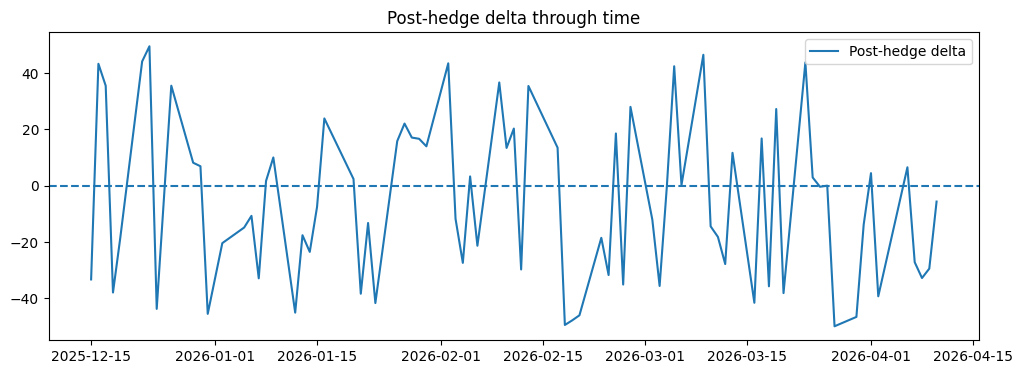

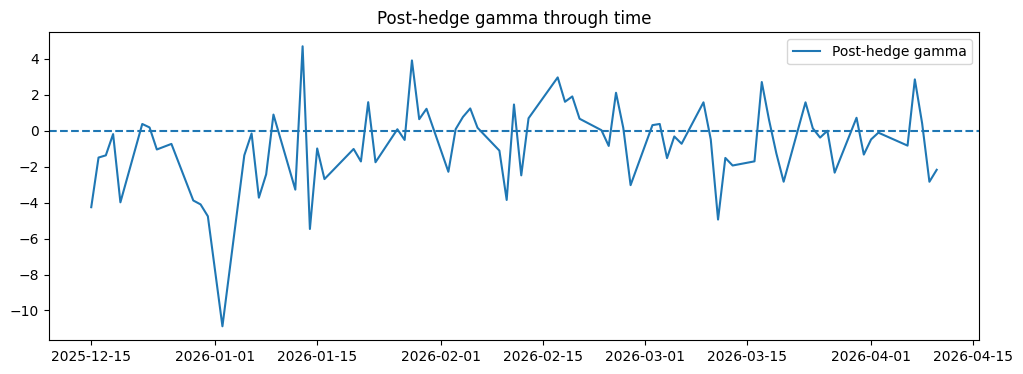

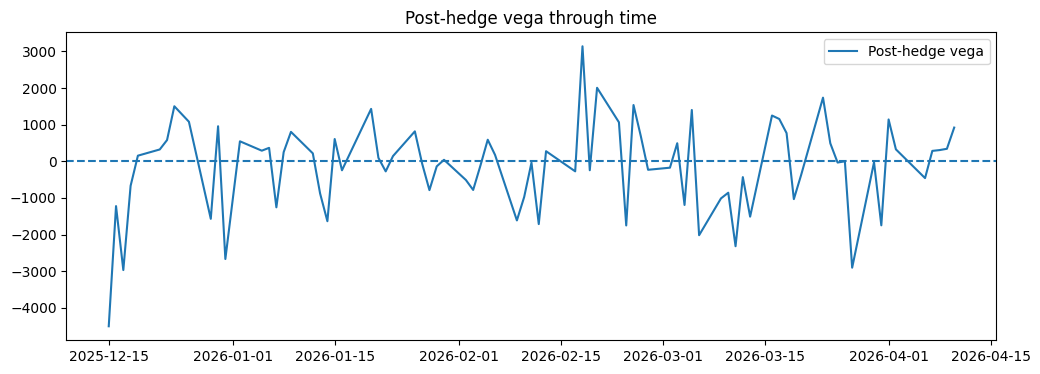

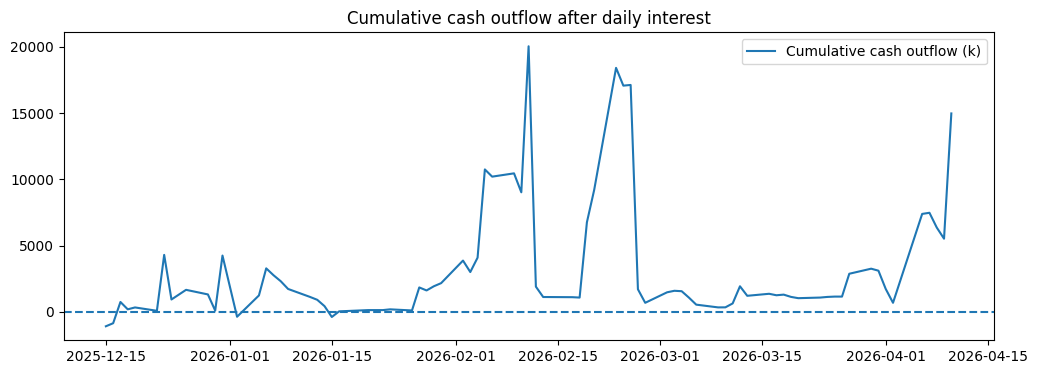

In [24]:
plt.figure(figsize=(12, 4))
plt.plot(history_df["trade_date"], history_df["post_delta"], label="Post-hedge delta")
plt.axhline(0.0, linestyle="--")
plt.title("Post-hedge delta through time")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(history_df["trade_date"], history_df["post_gamma"], label="Post-hedge gamma")
plt.axhline(0.0, linestyle="--")
plt.title("Post-hedge gamma through time")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(history_df["trade_date"], history_df["post_vega"], label="Post-hedge vega")
plt.axhline(0.0, linestyle="--")
plt.title("Post-hedge vega through time")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(history_df["trade_date"], history_df["cumulative_cash_outflow_after_interest_k"], label="Cumulative cash outflow (k)")
plt.axhline(0.0, linestyle="--")
plt.title("Cumulative cash outflow after daily interest")
plt.legend()
plt.show()

## 8. Final position book
This should be flat after the base-expiry liquidation step.


In [25]:
last_day_panel = panel_df.loc[panel_df["trade_date"] == history_df["trade_date"].max()].copy()

final_summary, final_details = portfolio_snapshot(
    day_panel=last_day_panel,
    option_positions=option_positions,
    stock_position=stock_position,
    contract_multiplier=CONTRACT_MULTIPLIER,
)

print("Final summary:")
display(pd.DataFrame([final_summary]))

print("Final option positions:")
display(final_details.sort_values("quantity_contracts", key=lambda s: s.abs(), ascending=False))

Final summary:


,stock_position_shares,option_value,total_delta,total_gamma,total_vega,total_theta
0,54000.0,-752467.726454,-5.652478,-2.170395,921.484405,476237.06264


Final option positions:


,contract_id,quantity_contracts,quantity_shares_equiv,price_per_share,delta_per_share,gamma_per_share,vega_per_share,theta_per_share,position_delta,position_gamma,position_vega,position_theta,position_value
0,2026-04-26|250.0|call,-1000.0,-100000.0,11.601954,0.856948,0.021382,12.303621,-33.637778,-85694.804929,-2138.232354,-1.230362e+06,3.363778e+06,-1.160195e+06
5,2026-04-17|260.0|call,313.0,31300.0,3.061161,0.542057,0.057839,14.309258,-75.185792,16966.381817,1810.372475,4.478798e+05,-2.353315e+06,9.581435e+04
1,2026-06-12|250.0|call,147.0,14700.0,15.490322,0.728032,0.015560,35.839263,-25.727680,10702.074966,228.734772,5.268372e+05,-3.781969e+05,2.277077e+05
4,2026-06-22|255.0|call,51.0,5100.0,12.932900,0.638799,0.016377,43.560863,-26.028016,3257.876268,83.522887,2.221604e+05,-1.327429e+05,6.595779e+04
2,2026-06-18|245.0|call,8.0,800.0,19.594944,0.793733,0.012668,32.195999,-22.564860,634.986149,10.134034,2.575680e+04,-1.805189e+04,1.567595e+04
3,2026-06-21|255.0|call,2.0,200.0,12.859332,0.639166,0.016489,43.247251,-26.169060,127.833251,3.297791,8.649450e+03,-5.233812e+03,2.571866e+03


In [26]:
# ---------------------------------------------------------
# Hook the DGV solver into the shared rolling-base comparison framework
# ---------------------------------------------------------

def ensure_theta_portfolio_snapshot():
    current_snapshot = portfolio_snapshot

    if getattr(current_snapshot, "_theta_safe_wrapper", False):
        return

    def portfolio_snapshot_theta_safe(day_panel, option_positions, stock_position=0.0, contract_multiplier=100):
        summary, details = current_snapshot(
            day_panel=day_panel,
            option_positions=option_positions,
            stock_position=stock_position,
            contract_multiplier=contract_multiplier,
        )

        if "total_theta" in summary:
            return summary, details

        df = day_panel.set_index("contract_id")
        total_theta = 0.0

        for cid, qty_contracts in option_positions.items():
            if (cid in df.index) and ("theta" in df.columns):
                total_theta += float(qty_contracts * contract_multiplier * float(df.loc[cid, "theta"]))

        summary = dict(summary)
        summary["total_theta"] = float(total_theta)

        if isinstance(details, pd.DataFrame) and (len(details) > 0):
            details = details.copy()
            if "theta_per_share" not in details.columns:
                theta_map = df["theta"] if "theta" in df.columns else pd.Series(dtype=float)
                details["theta_per_share"] = details["contract_id"].map(theta_map)
            if ("position_theta" not in details.columns) and ("quantity_shares_equiv" in details.columns):
                details["position_theta"] = details["quantity_shares_equiv"] * details["theta_per_share"].fillna(0.0)

        return summary, details

    portfolio_snapshot_theta_safe._theta_safe_wrapper = True
    globals()["portfolio_snapshot"] = portfolio_snapshot_theta_safe


ensure_theta_portfolio_snapshot()


def solve_delta_gamma_vega(
    day_panel,
    base_contract_id,
    base_contracts,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    if "find_best_daily_rebalance" not in globals():
        raise NameError(
            "Run the DGV helper cells above before registering solve_delta_gamma_vega."
        )

    short_dte_range = globals().get(
        "SHORT_HEDGE_DTE_RANGE",
        (max(7, target_hedge_dte // 2), max(14, target_hedge_dte)),
    )
    long_dte_range = globals().get(
        "LONG_HEDGE_DTE_RANGE",
        (max(target_hedge_dte + 15, 45), max(target_hedge_dte + 45, 90)),
    )

    base_book = build_live_base_book(day_panel, base_contract_id, base_contracts)

    rebalance = find_best_daily_rebalance(
        day_panel=day_panel,
        option_positions=base_book,
        stock_position=0.0,
        exclude_contract_ids={base_contract_id},
        max_new_candidates_per_bucket=globals().get(
            "MAX_NEW_CANDIDATES_PER_BUCKET",
            max_candidates,
        ),
        short_dte_range=short_dte_range,
        long_dte_range=long_dte_range,
        option_search_radius=option_search_radius,
        condition_number_limit=globals().get("CONDITION_NUMBER_LIMIT", 5000),
        quantity_penalty=globals().get("QUANTITY_PENALTY", 0.05),
        turnover_penalty=globals().get("TURNOVER_PENALTY", 0.01),
        inventory_penalty_weight=globals().get("INVENTORY_PENALTY_WEIGHT", 0.02),
        max_abs_option_trade=globals().get("MAX_ABS_OPTION_TRADE", 3000),
        max_abs_stock_position=globals().get("MAX_ABS_STOCK_POSITION", 150_000),
        max_gross_option_contracts=globals().get("MAX_GROSS_OPTION_CONTRACTS", 5000),
        contract_multiplier=contract_multiplier,
    )

    if rebalance is None:
        return solve_delta(
            day_panel=day_panel,
            base_contract_id=base_contract_id,
            base_contracts=base_contracts,
            target_hedge_dte=target_hedge_dte,
            max_candidates=max_candidates,
            option_search_radius=option_search_radius,
            contract_multiplier=contract_multiplier,
            stock_round_lot=stock_round_lot,
        )

    target_option_book = clean_position_book(
        rebalance["post_option_positions"],
        day_panel,
    )
    target_stock_position = float(rebalance["post_stock_position"])
    stock_position_theory = float(rebalance["q_stock_theory"])
    stock_position_actual = float(rebalance["post_stock_position"])
    residual_objective = float(rebalance["objective"])

    selected_hedge_id = (
        f"{rebalance['contract_a']} ({rebalance['q_a_actual']:+.0f}) | "
        f"{rebalance['contract_b']} ({rebalance['q_b_actual']:+.0f})"
    )

    return {
        "selected_hedge_id": selected_hedge_id,
        "target_option_book": target_option_book,
        "target_stock_position": target_stock_position,
        "hedge_contracts_theory": np.nan,
        "hedge_contracts_actual": np.nan,
        "stock_position_theory": stock_position_theory,
        "stock_position_actual": stock_position_actual,
        "targeted_greek": "delta_gamma_vega",
        "residual_objective": residual_objective,
    }


STRATEGY_SOLVERS["delta_gamma_vega"] = solve_delta_gamma_vega
strategies_to_compare = STRATEGIES_TO_RUN + ["delta_gamma_vega"]

combined_history_df, combined_trade_log_df = run_multiple_strategies(
    panel_df=panel_df,
    regime_df=regime_df,
    strategies_to_run=strategies_to_compare,
    initial_underlying_shares=INITIAL_UNDERLYING_SHARES,
    base_option_type=BASE_OPTION_TYPE,
    base_position_sign=BASE_POSITION_SIGN,
    target_entry_dte=TARGET_ENTRY_DTE,
    target_hedge_dte=TARGET_HEDGE_DTE,
    contract_multiplier=CONTRACT_MULTIPLIER,
    max_single_candidates=MAX_SINGLE_CANDIDATES,
    option_search_radius=OPTION_SEARCH_RADIUS,
    stock_round_lot=STOCK_ROUND_LOT,
    use_daily_risk_free_rate_for_cash=USE_DAILY_RISK_FREE_RATE_FOR_CASH,
    manual_cash_rate=MANUAL_CASH_RATE,
)

coverage_df = build_hedge_coverage_table(combined_history_df)
regime_summary_df = summarise_results(combined_history_df, sample_view="regime")
executed_summary_df = summarise_results(combined_history_df, sample_view="executed")

validation_df = (
    combined_history_df
    .groupby(["strategy", "regime"], as_index=False)
    .agg(
        n_days=("trade_date", "count"),
        n_eligible_days=("hedge_eligible_day", "sum"),
        n_executed_days=("hedge_executed_day", "sum"),
        avg_abs_pre_delta=("pre_delta", lambda s: float(np.mean(np.abs(s)))),
        avg_abs_pre_gamma=("pre_gamma", lambda s: float(np.mean(np.abs(s)))),
        avg_abs_pre_vega=("pre_vega", lambda s: float(np.mean(np.abs(s)))),
        avg_abs_post_delta=("post_delta", lambda s: float(np.mean(np.abs(s)))),
        avg_abs_post_gamma=("post_gamma", lambda s: float(np.mean(np.abs(s)))),
        avg_abs_post_vega=("post_vega", lambda s: float(np.mean(np.abs(s)))),
    )
    .sort_values(["strategy", "regime"])
    .reset_index(drop=True)
)

effectiveness_regime_df = compute_effectiveness_metrics(combined_history_df, sample_view="regime")
effectiveness_executed_df = compute_effectiveness_metrics(combined_history_df, sample_view="executed")

bootstrap_post_delta_df = bootstrap_metric_ci(combined_history_df, "post_delta", sample_view="executed", n_boot=500)
bootstrap_post_gamma_df = bootstrap_metric_ci(combined_history_df, "post_gamma", sample_view="executed", n_boot=500)
bootstrap_post_vega_df  = bootstrap_metric_ci(combined_history_df, "post_vega",  sample_view="executed", n_boot=500)

bootstrap_ci_df = pd.concat(
    [bootstrap_post_delta_df, bootstrap_post_gamma_df, bootstrap_post_vega_df],
    ignore_index=True,
)

print("Final unified comparison includes:", sorted(combined_history_df["strategy"].unique()))
display(coverage_df)
display(regime_summary_df)
display(executed_summary_df)


Final unified comparison includes: ['delta', 'delta_gamma', 'delta_gamma_vega', 'delta_theta', 'delta_vega']


,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,eligibility_pct_of_regime,execution_pct_of_regime,hedge_coverage_pct,top_no_hedge_reason
0,delta,high,14,14,11,100.0,78.571429,78.571429,no_trade_in_high_vol_regime
1,delta,low,12,12,12,100.0,100.000000,100.000000,
2,delta,medium,54,54,50,100.0,92.592593,92.592593,no_candidate_option
3,delta_gamma,high,14,14,13,100.0,92.857143,92.857143,solver_returned_no_trade
4,delta_gamma,low,12,12,12,100.0,100.000000,100.000000,
5,delta_gamma,medium,54,54,51,100.0,94.444444,94.444444,solver_returned_no_trade
6,delta_gamma_vega,high,14,14,13,100.0,92.857143,92.857143,solver_returned_no_trade
7,delta_gamma_vega,low,12,12,12,100.0,100.000000,100.000000,
8,delta_gamma_vega,medium,54,54,51,100.0,94.444444,94.444444,solver_returned_no_trade
9,delta_theta,high,14,14,13,100.0,92.857143,92.857143,solver_returned_no_trade


,sample_view,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_pre_delta,mean_abs_post_delta,pct_reduction_delta,mean_abs_pre_gamma,mean_abs_post_gamma,pct_reduction_gamma,mean_abs_pre_vega,mean_abs_post_vega,pct_reduction_vega,mean_abs_post_theta,total_option_turnover,total_stock_turnover,final_cash_outflow,avg_daily_cashflow
0,regime,delta,high,14,14,11,78.571429,7078.151942,27.087594,99.617307,1010.219891,1010.219891,0.000000,1.076516e+06,1.076516e+06,0.000000,2.651027e+06,0.0,99000.0,1.518567e+07,529081.030014
1,regime,delta,low,12,12,12,100.000000,5297.936952,23.119967,99.563604,3109.071300,3109.071300,0.000000,2.675451e+06,2.675451e+06,0.000000,2.658551e+06,0.0,63600.0,9.253991e+05,-814500.241343
2,regime,delta,medium,54,54,50,92.592593,8830.822731,19.081173,99.783925,1906.627936,1906.627936,0.000000,1.401014e+06,1.401014e+06,0.000000,2.916201e+06,0.0,476900.0,2.147090e+07,439274.180151
3,regime,delta_gamma,high,14,14,13,92.857143,5050.487845,30.053227,99.404944,297.120515,0.057924,99.980505,7.246952e+05,3.630854e+05,49.898193,3.916233e+04,13014.0,106300.0,-1.841388e+06,382199.832823
4,regime,delta_gamma,low,12,12,12,100.000000,796.499035,23.003470,97.111927,234.915216,0.061950,99.973629,7.842891e+05,6.143710e+05,21.665242,1.144130e+05,22517.0,101000.0,-3.032975e+06,-508280.358255
5,regime,delta_gamma,medium,54,54,51,94.444444,4504.942578,21.644387,99.519541,504.295663,0.074099,99.985306,1.168716e+06,9.824740e+05,15.935634,2.151674e+05,77286.0,739100.0,1.031566e+07,204823.089307
6,regime,delta_gamma_vega,high,14,14,13,92.857143,5053.686062,24.203834,99.521066,358.149869,1.922708,99.463156,3.164427e+05,1.667428e+03,99.473071,6.252870e+04,10199.0,79400.0,1.671106e+06,-563248.499523
7,regime,delta_gamma_vega,low,12,12,12,100.000000,1098.621552,20.721758,98.113840,409.066394,2.200112,99.462163,1.558585e+05,2.118612e+03,98.640682,4.634637e+04,16734.0,35900.0,5.543087e+04,184948.964645
8,regime,delta_gamma_vega,medium,54,54,51,94.444444,4476.196453,22.147309,99.505220,523.992898,1.786586,99.659044,3.164721e+05,1.598801e+03,99.494805,1.944861e+05,51224.0,461900.0,1.448570e+07,372543.188819
9,regime,delta_theta,high,14,14,13,92.857143,4892.455794,20.238556,99.586331,262.963837,16.313221,93.796401,5.806819e+05,5.981963e+05,-3.016176,1.684892e+02,13869.0,78900.0,-1.502232e+06,-226887.549925


,sample_view,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_pre_delta,mean_abs_post_delta,pct_reduction_delta,mean_abs_pre_gamma,mean_abs_post_gamma,pct_reduction_gamma,mean_abs_pre_vega,mean_abs_post_vega,pct_reduction_vega,mean_abs_post_theta,total_option_turnover,total_stock_turnover,final_cash_outflow,avg_daily_cashflow
0,executed,delta,high,14,14,11,78.571429,9004.420814,30.338916,99.663066,1275.630889,1275.630889,0.000000,1.366869e+06,1.366869e+06,0.000000,3.350676e+06,0.0,99000.0,1.518567e+07,673375.856381
1,executed,delta,low,12,12,12,100.000000,5297.936952,23.119967,99.563604,3109.071300,3109.071300,0.000000,2.675451e+06,2.675451e+06,0.000000,2.658551e+06,0.0,63600.0,9.253991e+05,-814500.241343
2,executed,delta,medium,54,54,50,92.592593,9537.286060,20.605177,99.783951,2059.155917,2059.155917,0.000000,1.513095e+06,1.513095e+06,0.000000,3.149495e+06,0.0,476900.0,2.147090e+07,474416.114563
3,executed,delta_gamma,high,14,14,13,92.857143,5438.986882,32.364987,99.404945,319.975895,0.062336,99.980519,7.804409e+05,3.910150e+05,49.898193,4.217470e+04,13014.0,106300.0,-1.841388e+06,411599.819964
4,executed,delta_gamma,low,12,12,12,100.000000,796.499035,23.003470,97.111927,234.915216,0.061950,99.973629,7.842891e+05,6.143710e+05,21.665242,1.144130e+05,22517.0,101000.0,-3.032975e+06,-508280.358255
5,executed,delta_gamma,medium,54,54,51,94.444444,4769.939148,22.917534,99.519542,533.960049,0.078394,99.985318,1.237464e+06,1.040267e+06,15.935634,2.278243e+05,77286.0,739100.0,1.031566e+07,216871.506325
6,executed,delta_gamma_vega,high,14,14,13,92.857143,5442.431117,26.065640,99.521066,385.699814,2.070564,99.463167,3.407845e+05,1.795689e+03,99.473072,6.733849e+04,10199.0,79400.0,1.671106e+06,-606575.307179
7,executed,delta_gamma_vega,low,12,12,12,100.000000,1098.621552,20.721758,98.113840,409.066394,2.200112,99.462163,1.558585e+05,2.118612e+03,98.640682,4.634637e+04,16734.0,35900.0,5.543087e+04,184948.964645
8,executed,delta_gamma_vega,medium,54,54,51,94.444444,4739.502074,23.450039,99.505221,554.815946,1.891615,99.659055,3.350881e+05,1.692839e+03,99.494808,2.059265e+05,51224.0,461900.0,1.448570e+07,394457.494043
9,executed,delta_theta,high,14,14,13,92.857143,5268.798520,21.795340,99.586332,283.191780,17.568039,93.796416,6.253497e+05,6.442114e+05,-3.016176,1.813410e+02,13869.0,78900.0,-1.502232e+06,-244340.438381


## 15. Final unified comparison plots and exports

The cells below produce the final presentation-ready comparison plots for all
five strategies on the same rolling-base framework:
- hedge coverage by regime
- absolute post-hedge delta
- absolute post-hedge gamma
- absolute post-hedge vega
- residual-risk vs turnover frontier
- cumulative cash outflow after interest


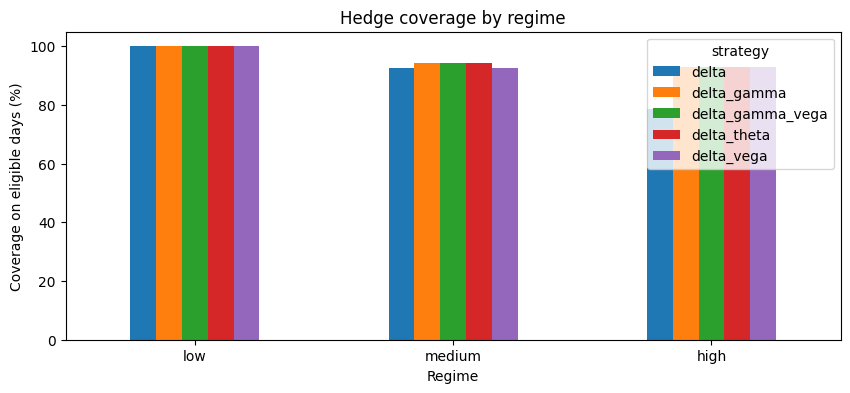

/var/folders/zr/hq_q97d52l1ck8p_4myglv4r0000gn/T/ipykernel_31923/1658813017.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


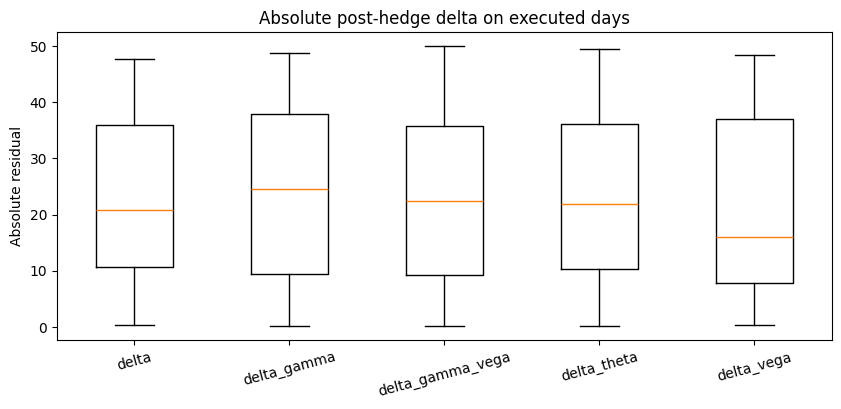

/var/folders/zr/hq_q97d52l1ck8p_4myglv4r0000gn/T/ipykernel_31923/1658813017.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


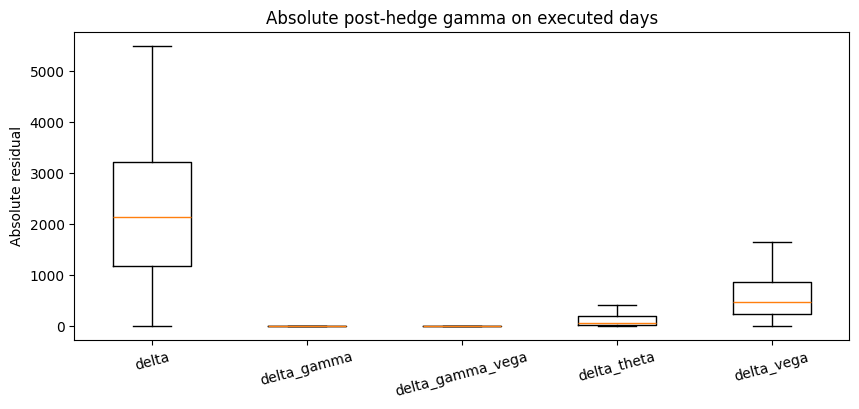

/var/folders/zr/hq_q97d52l1ck8p_4myglv4r0000gn/T/ipykernel_31923/1658813017.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


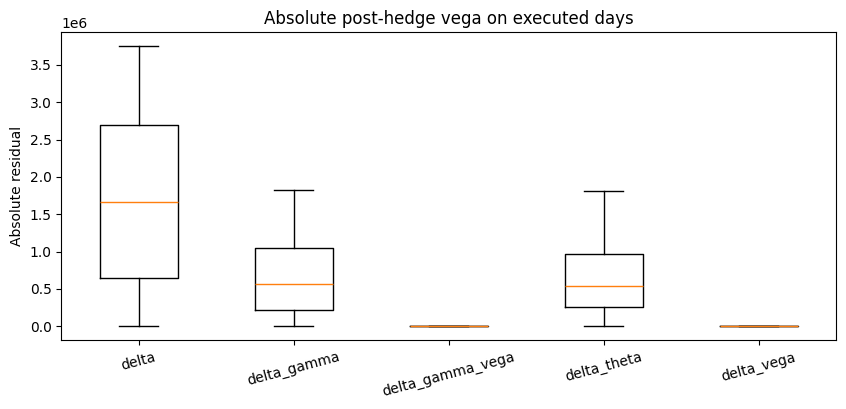

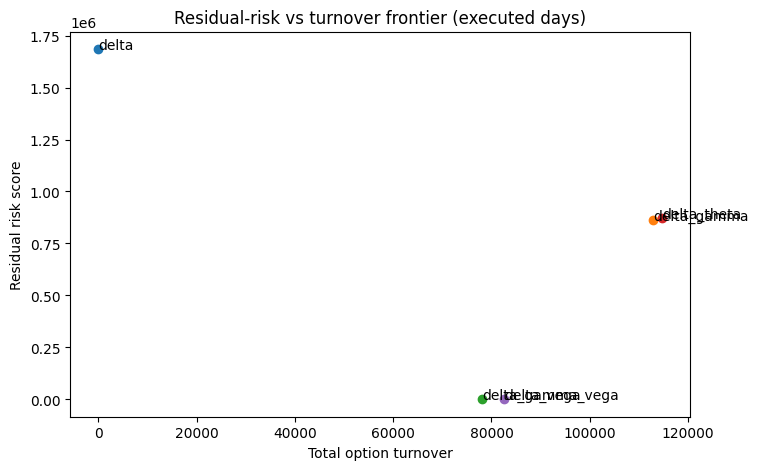

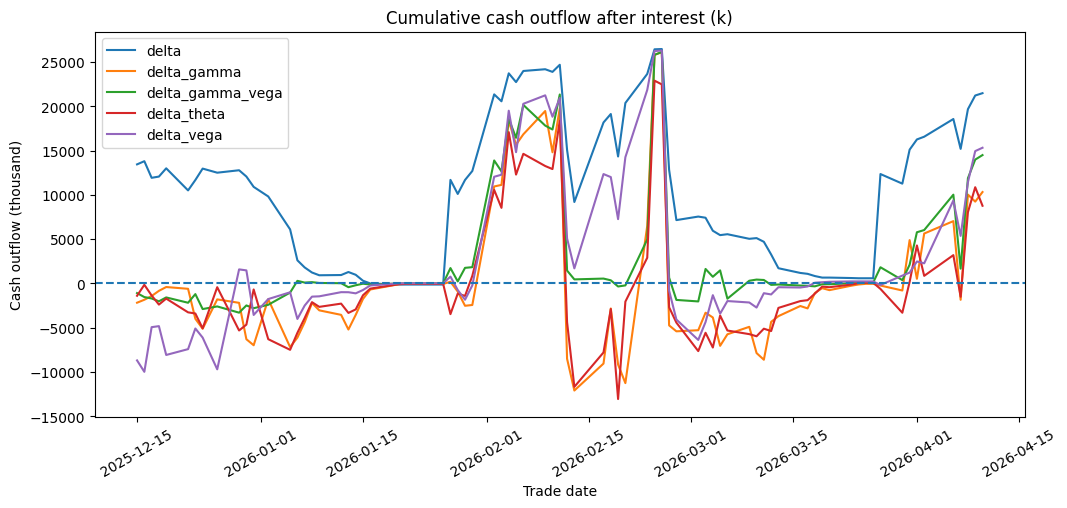

In [27]:
plot_df = combined_history_df.copy()

coverage_plot_df = build_hedge_coverage_table(plot_df)
coverage_pivot = (
    coverage_plot_df
    .pivot(index="regime", columns="strategy", values="hedge_coverage_pct")
    .reindex(index=["low", "medium", "high"])
)
coverage_pivot.plot(kind="bar", figsize=(10, 4))
plt.title("Hedge coverage by regime")
plt.xlabel("Regime")
plt.ylabel("Coverage on eligible days (%)")
plt.xticks(rotation=0)
plt.show()

executed_history_df = hedge_executed_days_only(plot_df)

for greek_col, title_text in [
    ("post_delta", "Absolute post-hedge delta on executed days"),
    ("post_gamma", "Absolute post-hedge gamma on executed days"),
    ("post_vega", "Absolute post-hedge vega on executed days"),
]:
    plt.figure(figsize=(10, 4))
    box_data = []
    labels = []

    for strat in sorted(executed_history_df["strategy"].dropna().unique()):
        strat_values = (
            executed_history_df.loc[executed_history_df["strategy"] == strat, greek_col]
            .abs()
            .dropna()
            .to_numpy()
        )
        if len(strat_values) > 0:
            box_data.append(strat_values)
            labels.append(strat)

    if len(box_data) > 0:
        plt.boxplot(box_data, labels=labels, showfliers=False)
        plt.title(title_text)
        plt.ylabel("Absolute residual")
        plt.xticks(rotation=15)
        plt.show()

frontier_df = compute_effectiveness_metrics(plot_df, sample_view="executed").reset_index()
frontier_df = frontier_df.dropna(subset=["residual_risk_score", "total_option_turnover"])

plt.figure(figsize=(8, 5))
for _, row in frontier_df.iterrows():
    plt.scatter(
        row["total_option_turnover"],
        row["residual_risk_score"],
        label=row["strategy"],
    )

plt.title("Residual-risk vs turnover frontier (executed days)")
plt.xlabel("Total option turnover")
plt.ylabel("Residual risk score")
plt.legend(title="Strategy")
plt.show()

plt.figure(figsize=(12, 5))
for strategy_name, sub in plot_df.groupby("strategy"):
    sub = sub.sort_values("trade_date")
    plt.plot(
        sub["trade_date"],
        sub["cumulative_cash_outflow_after_interest"] / 1000.0,
        label=strategy_name,
    )

plt.axhline(0.0, linestyle="--")
plt.title("Cumulative cash outflow after interest (k)")
plt.xlabel("Trade date")
plt.ylabel("Cash outflow (thousand)")
plt.legend()
plt.xticks(rotation=30)
plt.show()


In [28]:
import numpy as np
import pandas as pd

def build_regime_comparison_table(combined_history_df):
    # 1) Summary on all regime-evaluation days
    regime_summary = summarise_results(combined_history_df, sample_view="regime").copy()

    # 2) Summary only on executed hedge days
    executed_summary = summarise_results(combined_history_df, sample_view="executed").copy()

    # Keep only the columns we need
    regime_keep = [
        "strategy", "regime",
        "n_regime_days", "n_eligible_days", "n_executed_days",
        "hedge_coverage_pct",
        "final_cash_outflow",
        "avg_daily_cashflow",
    ]

    executed_keep = [
        "strategy", "regime",
        "mean_abs_post_delta",
        "mean_abs_post_gamma",
        "mean_abs_post_vega",
        "mean_abs_post_theta",
        "total_option_turnover",
        "total_stock_turnover",
    ]

    regime_tbl = regime_summary[regime_keep].copy()
    executed_tbl = executed_summary[executed_keep].copy()

    # Merge
    comparison = regime_tbl.merge(
        executed_tbl,
        on=["strategy", "regime"],
        how="left",
        suffixes=("_regime", "_executed")
    )

    # Use absolute final cash outflow magnitude as funding burden
    # because a large negative number is not automatically "better"
    comparison["abs_final_cash_outflow"] = comparison["final_cash_outflow"].abs()

    # ----------------------------
    # Rank metrics within each regime
    # Lower is better for these:
    #   - residual post-hedge Greeks
    #   - turnover
    #   - abs funding burden
    # Higher is better for coverage
    # ----------------------------
    lower_better_metrics = [
        "mean_abs_post_delta",
        "mean_abs_post_gamma",
        "mean_abs_post_vega",
        "total_option_turnover",
        "abs_final_cash_outflow",
    ]

    higher_better_metrics = [
        "hedge_coverage_pct",
    ]

    for col in lower_better_metrics:
        comparison[f"rank_{col}"] = comparison.groupby("regime")[col].rank(
            ascending=True, method="dense"
        )

    for col in higher_better_metrics:
        comparison[f"rank_{col}"] = comparison.groupby("regime")[col].rank(
            ascending=False, method="dense"
        )

    # Composite ranks
    comparison["hedge_quality_rank"] = comparison[
        [
            "rank_mean_abs_post_delta",
            "rank_mean_abs_post_gamma",
            "rank_mean_abs_post_vega",
        ]
    ].mean(axis=1)

    comparison["implementation_rank"] = comparison[
        [
            "rank_total_option_turnover",
            "rank_abs_final_cash_outflow",
        ]
    ].mean(axis=1)

    comparison["coverage_rank"] = comparison["rank_hedge_coverage_pct"]

    # Overall score: lower is better
    comparison["overall_score"] = (
        0.50 * comparison["hedge_quality_rank"] +
        0.30 * comparison["implementation_rank"] +
        0.20 * comparison["coverage_rank"]
    )

    comparison["overall_rank"] = comparison.groupby("regime")["overall_score"].rank(
        ascending=True, method="dense"
    )

    # Neater ordering
    ordered_cols = [
        "strategy", "regime",
        "n_regime_days", "n_eligible_days", "n_executed_days", "hedge_coverage_pct",
        "mean_abs_post_delta", "mean_abs_post_gamma", "mean_abs_post_vega",
        "total_option_turnover", "total_stock_turnover",
        "final_cash_outflow", "abs_final_cash_outflow",
        "hedge_quality_rank", "implementation_rank", "coverage_rank",
        "overall_score", "overall_rank",
    ]

    return comparison[ordered_cols].sort_values(["regime", "overall_rank", "strategy"]).reset_index(drop=True)

In [29]:
import numpy as np
import pandas as pd

def build_regime_metric_tables(combined_history_df):
    # Regime-day metrics: coverage and funding burden
    regime_summary = summarise_results(combined_history_df, sample_view="regime").copy()

    # Executed-day metrics: post-hedge quality and turnover
    executed_summary = summarise_results(combined_history_df, sample_view="executed").copy()

    regime_cols = [
        "strategy", "regime",
        "n_regime_days", "n_eligible_days", "n_executed_days",
        "hedge_coverage_pct",
        "final_cash_outflow",
    ]

    executed_cols = [
        "strategy", "regime",
        "mean_abs_post_delta",
        "mean_abs_post_gamma",
        "mean_abs_post_vega",
        "total_option_turnover",
    ]

    df = regime_summary[regime_cols].merge(
        executed_summary[executed_cols],
        on=["strategy", "regime"],
        how="left"
    )

    # Use absolute cash burden for cost comparison
    df["abs_final_cash_outflow"] = df["final_cash_outflow"].abs()

    regime_tables = {}

    for regime, sub in df.groupby("regime", sort=True):
        sub = sub.copy()

        # -----------------------------------
        # Hedge quality
        # lower post-hedge Greeks = better
        # -----------------------------------
        sub["rank_post_delta"] = sub["mean_abs_post_delta"].rank(ascending=True, method="dense")
        sub["rank_post_gamma"] = sub["mean_abs_post_gamma"].rank(ascending=True, method="dense")
        sub["rank_post_vega"] = sub["mean_abs_post_vega"].rank(ascending=True, method="dense")

        sub["hedge_quality_score"] = sub[
            ["rank_post_delta", "rank_post_gamma", "rank_post_vega"]
        ].mean(axis=1)

        sub["hedge_quality_rank"] = sub["hedge_quality_score"].rank(
            ascending=True, method="dense"
        )

        # -----------------------------------
        # Cost efficiency
        # lower turnover + lower cash burden = better
        # -----------------------------------
        sub["rank_turnover"] = sub["total_option_turnover"].rank(ascending=True, method="dense")
        sub["rank_cash_burden"] = sub["abs_final_cash_outflow"].rank(ascending=True, method="dense")

        sub["cost_efficiency_score"] = sub[
            ["rank_turnover", "rank_cash_burden"]
        ].mean(axis=1)

        sub["cost_efficiency_rank"] = sub["cost_efficiency_score"].rank(
            ascending=True, method="dense"
        )

        # -----------------------------------
        # Coverage
        # higher coverage = better
        # -----------------------------------
        sub["coverage_rank"] = sub["hedge_coverage_pct"].rank(
            ascending=False, method="dense"
        )

        # Verdict tags
        sub["best_hedge_quality"] = np.where(sub["hedge_quality_rank"] == 1, "Yes", "")
        sub["best_cost_efficiency"] = np.where(sub["cost_efficiency_rank"] == 1, "Yes", "")
        sub["best_coverage"] = np.where(sub["coverage_rank"] == 1, "Yes", "")

        # Final presentation columns
        out = sub[
            [
                "strategy",
                "n_regime_days", "n_eligible_days", "n_executed_days",
                "hedge_coverage_pct", "coverage_rank",
                "mean_abs_post_delta", "mean_abs_post_gamma", "mean_abs_post_vega",
                "hedge_quality_score", "hedge_quality_rank",
                "total_option_turnover", "abs_final_cash_outflow",
                "cost_efficiency_score", "cost_efficiency_rank",
                "best_hedge_quality", "best_cost_efficiency", "best_coverage",
            ]
        ].copy()

        # Round for neat display
        round_cols = [
            "hedge_coverage_pct",
            "mean_abs_post_delta", "mean_abs_post_gamma", "mean_abs_post_vega",
            "hedge_quality_score",
            "total_option_turnover", "abs_final_cash_outflow",
            "cost_efficiency_score",
        ]
        out[round_cols] = out[round_cols].round(2)

        out = out.sort_values(
            ["hedge_quality_rank", "cost_efficiency_rank", "coverage_rank", "strategy"]
        ).reset_index(drop=True)

        regime_tables[regime] = out

    return regime_tables

regime_tables = build_regime_metric_tables(combined_history_df)

for regime, table in regime_tables.items():
    print(f"\n=== {regime.upper()} VOLATILITY REGIME ===")
    display(table)


=== HIGH VOLATILITY REGIME ===


,strategy,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,coverage_rank,mean_abs_post_delta,mean_abs_post_gamma,mean_abs_post_vega,hedge_quality_score,hedge_quality_rank,total_option_turnover,abs_final_cash_outflow,cost_efficiency_score,cost_efficiency_rank,best_hedge_quality,best_cost_efficiency,best_coverage
0,delta_gamma_vega,14,14,13,92.86,1.0,26.07,2.07,1795.69,2.33,1.0,10199.0,1671106.46,2.0,1.0,Yes,Yes,Yes
1,delta_vega,14,14,13,92.86,1.0,22.06,338.79,123.75,2.33,1.0,10387.0,5370017.82,3.5,3.0,Yes,,Yes
2,delta_theta,14,14,13,92.86,1.0,21.80,17.57,644211.39,2.67,2.0,13869.0,1502232.31,3.0,2.0,,,Yes
3,delta_gamma,14,14,13,92.86,1.0,32.36,0.06,391015.02,3.00,3.0,13014.0,1841388.16,3.5,3.0,,,Yes
4,delta,14,14,11,78.57,2.0,30.34,1275.63,1366868.69,4.67,4.0,0.0,15185667.94,3.0,2.0,,,



=== LOW VOLATILITY REGIME ===


,strategy,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,coverage_rank,mean_abs_post_delta,mean_abs_post_gamma,mean_abs_post_vega,hedge_quality_score,hedge_quality_rank,total_option_turnover,abs_final_cash_outflow,cost_efficiency_score,cost_efficiency_rank,best_hedge_quality,best_cost_efficiency,best_coverage
0,delta_vega,12,12,12,100.0,1.0,17.61,756.17,111.16,2.00,1.0,18853.0,1451577.41,3.0,2.0,Yes,,Yes
1,delta_gamma_vega,12,12,12,100.0,1.0,20.72,2.20,2118.61,2.33,2.0,16734.0,55430.87,1.5,1.0,,Yes,Yes
2,delta_theta,12,12,12,100.0,1.0,20.01,149.30,463480.49,2.67,3.0,21692.0,2640277.01,4.0,3.0,,,Yes
3,delta_gamma,12,12,12,100.0,1.0,23.00,0.06,614370.98,3.00,4.0,22517.0,3032974.91,5.0,4.0,,,Yes
4,delta,12,12,12,100.0,1.0,23.12,3109.07,2675450.69,5.00,5.0,0.0,925399.09,1.5,1.0,,Yes,Yes



=== MEDIUM VOLATILITY REGIME ===


,strategy,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,coverage_rank,mean_abs_post_delta,mean_abs_post_gamma,mean_abs_post_vega,hedge_quality_score,hedge_quality_rank,total_option_turnover,abs_final_cash_outflow,cost_efficiency_score,cost_efficiency_rank,best_hedge_quality,best_cost_efficiency,best_coverage
0,delta_vega,54,54,50,92.59,2.0,21.44,849.42,80.48,2.33,1.0,53337.0,15312999.06,3.5,3.0,Yes,,
1,delta_gamma_vega,54,54,51,94.44,1.0,23.45,1.89,1692.84,2.67,2.0,51224.0,14485696.15,2.5,1.0,,Yes,Yes
2,delta_gamma,54,54,51,94.44,1.0,22.92,0.08,1040266.63,2.67,2.0,77286.0,10315664.52,3.0,2.0,,,Yes
3,delta_theta,54,54,51,94.44,1.0,23.89,145.74,1025188.47,3.67,3.0,79096.0,8766780.75,3.0,2.0,,,Yes
4,delta,54,54,50,92.59,2.0,20.61,2059.16,1513095.11,3.67,3.0,0.0,21470897.98,3.0,2.0,,,


In [30]:
def build_regime_verdict_table(comparison_table):
    verdict_rows = []

    for regime, sub in comparison_table.groupby("regime", sort=True):
        sub = sub.sort_values(["overall_rank", "overall_score", "strategy"]).reset_index(drop=True)

        best_hedge_quality = sub.loc[sub["hedge_quality_rank"].idxmin(), "strategy"]
        best_cost_efficiency = sub.loc[sub["implementation_rank"].idxmin(), "strategy"]
        best_coverage = sub.loc[sub["coverage_rank"].idxmin(), "strategy"]
        best_overall = sub.loc[sub["overall_rank"].idxmin(), "strategy"]
        least_effective = sub.loc[sub["overall_rank"].idxmax(), "strategy"]

        verdict_rows.append(
            {
                "regime": regime,
                "best_hedge_quality": best_hedge_quality,
                "best_cost_efficiency": best_cost_efficiency,
                "best_coverage": best_coverage,
                "best_overall_tradeoff": best_overall,
                "least_effective": least_effective,
            }
        )

    return pd.DataFrame(verdict_rows)

regime_comparison_table = build_regime_comparison_table(combined_history_df)
regime_verdict_table = build_regime_verdict_table(regime_comparison_table)

display(regime_comparison_table)
display(regime_verdict_table)

,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_post_delta,mean_abs_post_gamma,mean_abs_post_vega,total_option_turnover,total_stock_turnover,final_cash_outflow,abs_final_cash_outflow,hedge_quality_rank,implementation_rank,coverage_rank,overall_score,overall_rank
0,delta_gamma_vega,high,14,14,13,92.857143,26.065640,2.070564,1.795689e+03,10199.0,79400.0,1.671106e+06,1.671106e+06,2.333333,2.0,1.0,1.966667,1.0
1,delta_vega,high,14,14,13,92.857143,22.061593,338.790937,1.237485e+02,10387.0,37200.0,5.370018e+06,5.370018e+06,2.333333,3.5,1.0,2.416667,2.0
2,delta_theta,high,14,14,13,92.857143,21.795340,17.568039,6.442114e+05,13869.0,78900.0,-1.502232e+06,1.502232e+06,2.666667,3.0,1.0,2.433333,3.0
3,delta_gamma,high,14,14,13,92.857143,32.364987,0.062336,3.910150e+05,13014.0,106300.0,-1.841388e+06,1.841388e+06,3.000000,3.5,1.0,2.750000,4.0
4,delta,high,14,14,11,78.571429,30.338916,1275.630889,1.366869e+06,0.0,99000.0,1.518567e+07,1.518567e+07,4.666667,3.0,2.0,3.633333,5.0
5,delta_gamma_vega,low,12,12,12,100.000000,20.721758,2.200112,2.118612e+03,16734.0,35900.0,5.543087e+04,5.543087e+04,2.333333,1.5,1.0,1.816667,1.0
6,delta_vega,low,12,12,12,100.000000,17.606136,756.172230,1.111562e+02,18853.0,124400.0,-1.451577e+06,1.451577e+06,2.000000,3.0,1.0,2.100000,2.0
7,delta_theta,low,12,12,12,100.000000,20.010483,149.295685,4.634805e+05,21692.0,107300.0,-2.640277e+06,2.640277e+06,2.666667,4.0,1.0,2.733333,3.0
8,delta,low,12,12,12,100.000000,23.119967,3109.071300,2.675451e+06,0.0,63600.0,9.253991e+05,9.253991e+05,5.000000,1.5,1.0,3.150000,4.0
9,delta_gamma,low,12,12,12,100.000000,23.003470,0.061950,6.143710e+05,22517.0,101000.0,-3.032975e+06,3.032975e+06,3.000000,5.0,1.0,3.200000,5.0


,regime,best_hedge_quality,best_cost_efficiency,best_coverage,best_overall_tradeoff,least_effective
0,high,delta_gamma_vega,delta_gamma_vega,delta_gamma_vega,delta_gamma_vega,delta
1,low,delta_vega,delta_gamma_vega,delta_gamma_vega,delta_gamma_vega,delta_gamma
2,medium,delta_vega,delta_gamma_vega,delta_gamma_vega,delta_gamma_vega,delta


In [31]:
import pandas as pd
import numpy as np

def build_compact_scorecards(regime_tables):
    compact_tables = {}

    for regime, table in regime_tables.items():
        df = table.copy()

        compact = df[
            [
                "strategy",
                "mean_abs_post_delta",
                "mean_abs_post_gamma",
                "mean_abs_post_vega",
                "total_option_turnover",
                "abs_final_cash_outflow",
                "hedge_coverage_pct",
                "hedge_quality_rank",
                "cost_efficiency_rank",
                "coverage_rank",
            ]
        ].copy()

        compact = compact.rename(columns={
            "mean_abs_post_delta": "|Post Δ|",
            "mean_abs_post_gamma": "|Post Γ|",
            "mean_abs_post_vega": "|Post V|",
            "total_option_turnover": "Turnover",
            "abs_final_cash_outflow": "|Cash Outflow|",
            "hedge_coverage_pct": "Coverage %",
            "hedge_quality_rank": "HQ Rank",
            "cost_efficiency_rank": "Cost Rank",
            "coverage_rank": "Coverage Rank",
        })

        compact_tables[regime] = compact

    return compact_tables

compact_tables = build_compact_scorecards(regime_tables)

def style_scorecard(df):
    lower_better_cols = ["|Post Δ|", "|Post Γ|", "|Post V|", "Turnover", "|Cash Outflow|", "HQ Rank", "Cost Rank", "Coverage Rank"]
    higher_better_cols = ["Coverage %"]

    styler = (
        df.style
        .format({
            "|Post Δ|": "{:,.2f}",
            "|Post Γ|": "{:,.2f}",
            "|Post V|": "{:,.2f}",
            "Turnover": "{:,.0f}",
            "|Cash Outflow|": "{:,.0f}",
            "Coverage %": "{:,.1f}",
            "HQ Rank": "{:.0f}",
            "Cost Rank": "{:.0f}",
            "Coverage Rank": "{:.0f}",
        })
        .background_gradient(cmap="RdYlGn_r", subset=lower_better_cols)
        .background_gradient(cmap="RdYlGn", subset=higher_better_cols)
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center")]},
            {"selector": "td", "props": [("padding", "6px")]},
        ])
    )
    return styler

for regime, df in compact_tables.items():
    print(f"\n=== {regime.upper()} VOLATILITY REGIME ===")
    display(style_scorecard(df))


=== HIGH VOLATILITY REGIME ===


,strategy,|Post Δ|,|Post Γ|,|Post V|,Turnover,|Cash Outflow|,Coverage %,HQ Rank,Cost Rank,Coverage Rank
0,delta_gamma_vega,26.07,2.07,"1,795.69","10,199","1,671,106",92.9,1,1,1
1,delta_vega,22.06,338.79,123.75,"10,387","5,370,018",92.9,1,3,1
2,delta_theta,21.80,17.57,"644,211.39","13,869","1,502,232",92.9,2,2,1
3,delta_gamma,32.36,0.06,"391,015.02","13,014","1,841,388",92.9,3,3,1
4,delta,30.34,"1,275.63","1,366,868.69",0,"15,185,668",78.6,4,2,2



=== LOW VOLATILITY REGIME ===


,strategy,|Post Δ|,|Post Γ|,|Post V|,Turnover,|Cash Outflow|,Coverage %,HQ Rank,Cost Rank,Coverage Rank
0,delta_vega,17.61,756.17,111.16,"18,853","1,451,577",100.0,1,2,1
1,delta_gamma_vega,20.72,2.20,"2,118.61","16,734","55,431",100.0,2,1,1
2,delta_theta,20.01,149.30,"463,480.49","21,692","2,640,277",100.0,3,3,1
3,delta_gamma,23.00,0.06,"614,370.98","22,517","3,032,975",100.0,4,4,1
4,delta,23.12,"3,109.07","2,675,450.69",0,"925,399",100.0,5,1,1



=== MEDIUM VOLATILITY REGIME ===


,strategy,|Post Δ|,|Post Γ|,|Post V|,Turnover,|Cash Outflow|,Coverage %,HQ Rank,Cost Rank,Coverage Rank
0,delta_vega,21.44,849.42,80.48,"53,337","15,312,999",92.6,1,3,2
1,delta_gamma_vega,23.45,1.89,"1,692.84","51,224","14,485,696",94.4,2,1,1
2,delta_gamma,22.92,0.08,"1,040,266.63","77,286","10,315,665",94.4,2,2,1
3,delta_theta,23.89,145.74,"1,025,188.47","79,096","8,766,781",94.4,3,2,1
4,delta,20.61,"2,059.16","1,513,095.11",0,"21,470,898",92.6,3,2,2


In [32]:
combined_history_df.to_csv("unified_greek_strategy_history.csv", index=False)
combined_trade_log_df.to_csv("unified_greek_strategy_trade_log.csv", index=False)
coverage_df.to_csv("unified_greek_strategy_coverage.csv", index=False)
regime_summary_df.to_csv("unified_greek_strategy_summary_regime_days.csv", index=False)
executed_summary_df.to_csv("unified_greek_strategy_summary_executed_days.csv", index=False)
validation_df.to_csv("unified_greek_strategy_validation_table.csv", index=False)
bootstrap_ci_df.to_csv("unified_greek_strategy_bootstrap_ci.csv", index=False)

panel_df.to_csv("persistent_option_panel_shared.csv", index=False)
regime_df.to_csv("regime_table_shared.csv", index=False)

for strategy_name in sorted(combined_history_df["strategy"].unique()):
    build_strategy_daily_table(combined_history_df, strategy_name).to_csv(
        f"{strategy_name}_daily_table.csv",
        index=False,
    )

print("Saved rolling-base unified comparison outputs to the current directory.")


Saved rolling-base unified comparison outputs to the current directory.


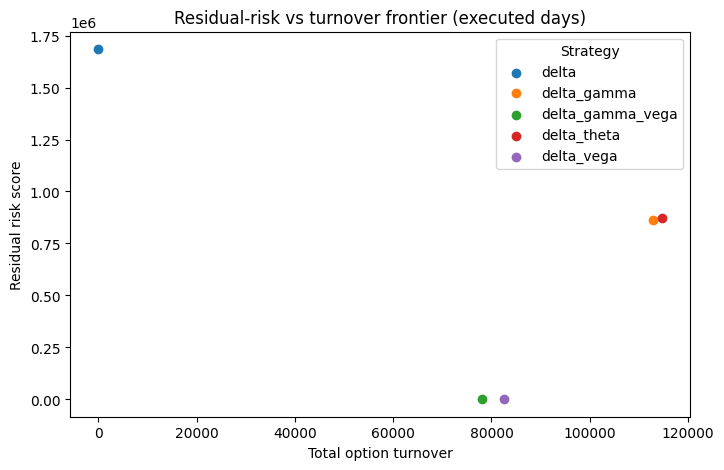

In [33]:
frontier_df = frontier_df.dropna(subset=["residual_risk_score", "total_option_turnover"])

plt.figure(figsize=(8, 5))
for _, row in frontier_df.iterrows():
    plt.scatter(
        row["total_option_turnover"],
        row["residual_risk_score"],
        label=row["strategy"],
    )

plt.title("Residual-risk vs turnover frontier (executed days)")
plt.xlabel("Total option turnover")
plt.ylabel("Residual risk score")
plt.legend(title="Strategy")
plt.show()